In [1]:
import pandas as pd
import numpy as np
from pathlib import Path


# 1. 用 Path() 包裹字符串
#FIGURE_DIR = Path(r"C:\usrspace\mywork\data_paper2\visibile_data\baseRaan_0\path")





# src_opju = fr"C:\usrspace\mywork\data_paper2\postdata\test.opju"
src_opju = fr"C:\usrspace\mywork\data_paper2\paper_need_data\two_raw_short_hop.opju"
# src_opju = fr"C:\usrspace\mywork\data_paper2\paper_need_data\24days.opju"

In [33]:
import math

def walker_repeat_period_from_altitude(
    h_km,
    max_days=100,
    tol=0.01
):
    """
    输入轨道高度，输出 Walker 星座相对于地球自转的回归周期（恒星日）

    Parameters
    ----------
    h_km : float
        轨道高度（km）
    max_days : int
        最大搜索的恒星日数
    tol : float
        可接受的圈数误差

    Returns
    -------
    dict
        {
            'altitude_km': h_km,
            'orbit_period_min': Ts,
            'orbits_per_sidereal_day': n,
            'sidereal_days': k,
            'satellite_orbits': m,
            'error': epsilon
        }
    """

    # ---------- 常数 ----------
    mu = 3.986004418e14       # m^3 / s^2
    Re = 6371e3               # m
    T_earth = 86164.0         # s (sidereal day)

    # ---------- 轨道周期 ----------
    r = Re + h_km * 1e3
    Ts = 2 * math.pi * math.sqrt(r**3 / mu)  # seconds
    Ts_min = Ts / 60

    # ---------- 圈数 ----------
    n = T_earth / Ts

    # ---------- 搜索回归周期 ----------
    for k in range(1, max_days + 1):
        m = round(k * n)
        error = abs(k * n - m)

        if error < tol:
            return {
                "altitude_km": h_km,
                "orbit_period_min": Ts_min,
                "orbits_per_sidereal_day": n,
                "sidereal_days": k,
                "satellite_orbits": m,
                "error": error
            }

    return None
res = walker_repeat_period_from_altitude(1066)
print(res)


{'altitude_km': 1066, 'orbit_period_min': 106.37912219397244, 'orbits_per_sidereal_day': 13.499516042707448, 'sidereal_days': 2, 'satellite_orbits': 27, 'error': 0.0009679145851038129}


In [ ]:
FIGURE_DIR = Path(r"C:\usrspace\mywork\data_paper2\visibile_data\G60_paper2_station\day_20250107\path")

In [ ]:
import draw.pymatlab2.origin_function.csv2origin as csv2origin

In [ ]:
FIGURE_DIR = Path(r"C:\usrspace\mywork\data_paper2\visibile_data\GW\path")


In [2]:
FIGURE_DIR = Path(r"C:\usrspace\mywork\data_paper2\paper_need_data\24_T_data\G60_24")


In [2]:
import originpro as op
import numpy as np
import pandas as pd
import  draw.pymatlab2.basic.get_mean_var as get_mean_var
import os

# Very useful, especially during development, when you are
# liable to have a few uncaught exceptions.
# Ensures that the Origin instance gets shut down properly.
# Note: only applicable to external Python.
import sys
import draw.pymatlab2.origin_function.write2origin as write2origin
def origin_shutdown_exception_hook(exctype, value, traceback):
    '''Ensures Origin gets shut down if an uncaught exception'''
    op.exit()
    sys.__excepthook__(exctype, value, traceback)
if op and op.oext:
    sys.excepthook = origin_shutdown_exception_hook

import  re
# Set Origin instance visibility.
# Important for only external Python.
# Should not be used with embedded Python.
if op.oext:
    op.set_show(True)


# Example of opening a project and reading data.

# We'll open the Tutorial Data.opju project that ships with Origin.
# src_opju = r"C:\usrspace\mywork\SIMULATION_EDITION.opju"   # <— 用绝对路径；注意路径和文件名是否正确
print("File exists? ", os.path.exists(src_opju))
ok = op.open(file=src_opju)
print("Project opened? ", ok)
import draw.pymatlab2.origin_function.csv2origin as csv2origin

import draw.pymatlab2.origin_function.fillgap as fillgap
from config import DATA_DIR,INPUT_DIR
from pathlib import Path

File exists?  True
Project opened?  True


In [ ]:



BOOKname = "Book2"
start_ts  =0
end_ts = 86400
TOTAL_START = start_ts
TOTAL_END = end_ts     # 测试总长度
CHUNK_SIZE = 10000    # 切片大小


# TTB_VALUES = [  10,20,30,40,50,60, 70, 80,90, 100, 110, 120,130,140]
# TTB_VALUES = [  60, 70, 80,90, 100, 110, 120,130,140]

for batch_start in range(TOTAL_START, TOTAL_END, CHUNK_SIZE):

    # 计算当前结束点
    batch_end = min(batch_start + CHUNK_SIZE, TOTAL_END)

    # 3. 现在可以使用 / 拼接了
    filename = f"avgspath_g0_4_baseline_{batch_start}_to_{batch_end}.csv"
    # filename = f"city2_{batch_start}_to_{batch_end}.csv"
    csv1_path = FIGURE_DIR / filename  # 完美运行


    csv2origin.csv_to_origin(csv1_path, book=BOOKname, sheet=filename, clear=True)


    print(f"\n>> 正在处理分片: {batch_start} 到 {batch_end} ...")





In [ ]:
FIGURE_DIR

# MergedData get ,ine sider
this section ,we get the mergedData and save it to futher process

In [ ]:

#
import pandas as pd
from pathlib import Path
import os
# 确保导入了你的 csv2origin
# import csv2origin

# ================= 配置参数 =================
BOOKname = "Book2"
start_ts = 0
end_ts = 86400
# end_ts = 50000

TOTAL_START = start_ts
TOTAL_END = end_ts
CHUNK_SIZE = 10000

# 假设 FIGURE_DIR 已经定义好
# FIGURE_DIR = Path(r"C:\usrspace\mywork\data_paper2\visibile_data\baseRaan_0\path")

# 用于存储所有分片数据的列表
all_data_frames = []

print(f"开始合并数据... 范围: {TOTAL_START} - {TOTAL_END}")

# ================= 1. 循环读取并合并 =================
for batch_start in range(TOTAL_START, TOTAL_END, CHUNK_SIZE):

    batch_end = min(batch_start + CHUNK_SIZE, TOTAL_END)

    # 构造文件名 (跟你生成时保持一致)
    filename = f"avgspath_g0_4_baseline_{batch_start}_to_{batch_end}.csv"
   #  filename = f"city2_{batch_start}_to_{batch_end}.csv"
    csv1_path = FIGURE_DIR / filename

    # 检查文件是否存在（防止某个分片因为没数据没生成）
    if csv1_path.exists():
        print(f"读取分片: {filename}")
        try:
            # 读取 CSV
            df = pd.read_csv(csv1_path)
            # 添加到列表
            all_data_frames.append(df)
        except Exception as e:
            print(f"  [Error] 读取 {filename} 失败: {e}")
    else:
        print(f"  [Warning] 文件不存在，跳过: {filename}")

# ================= 2. 合并、排序与保存 =================
if all_data_frames:
    # 2.1 合并所有 DataFrame
    # ignore_index=True 会重置索引，避免重复
    merged_df = pd.concat(all_data_frames, ignore_index=True)

    # 2.2 按时间顺序排序 (关键步骤)
    # 假设你的第一列是时间 (Time 或 step)。
    # 如果你知道列名，最好用 by='Time'；如果不知道，用 iloc[:, 0] 表示第一列
    time_col_name = merged_df.columns[0] # 自动获取第一列的列名
    print(f"正在按列 '{time_col_name}' 进行排序...")
    merged_df.sort_values(by=time_col_name, ascending=True, inplace=True)
# ================= 新增：保留一个恒星日的数据 =================
    # 2.3 截断数据，只保留第一列时间 <= 86164 秒的数据
    print("正在截断数据，仅保留前 86164 秒（一个恒星日）内的数据...")
    merged_df = merged_df[merged_df[time_col_name] <= 86164]


    # 2.3 构造合并后的文件名
    merged_filename = f"avgspath_g0_4_baseline_ALL_{TOTAL_START}_to_{TOTAL_END}.csv"
    merged_csv_path = FIGURE_DIR / merged_filename

    # 2.4 保存为一个大的 CSV
    merged_df.to_csv(merged_csv_path, index=False)
    print(f"合并完成！已保存为: {merged_csv_path}")

    # ================= 3. 导入到 Origin =================
    # 只调用一次 Origin 接口
    # sheet 名可以叫 "MergedData" 或者简单的 "All"
    print("正在导入到 Origin...")
    csv2origin.csv_to_origin(
        merged_csv_path,
        book=BOOKname,
        sheet="MergedData", # 所有数据在一个 Sheet
        clear=True
    )
    print("Origin 导入完成。")

else:
    print("错误：没有找到任何 CSV 文件，无法合并。")

# 这里的函数，是为了求解上述功能块的 MergeData的各项数值


## 求解最值

## get the mean of all the mergeddata

In [ ]:
# 这里的函数，是为了求解上述功能块的 MergeData的各项数值
TARGET_BOOK = "GW"
sheetname   = "MergedData"

wks = op.find_sheet('w', f'[{TARGET_BOOK}]{sheetname}')

if wks is None:
    raise RuntimeError("找不到指定工作表")

df = wks.to_df(head='L')

df["avg_shortest_path"].mean()

## get the offset of the mergeddata function

In [6]:
# 这里的函数，是为了求解上述功能块的 MergeData的各项数值
TARGET_BOOK = "GW"
sheetname   = "MergedData"

wks = op.find_sheet('w', f'[{TARGET_BOOK}]{sheetname}')

if wks is None:
    raise RuntimeError("找不到指定工作表")

GW_line = wks.to_df(head='L')

GW_line["avg_shortest_path"].mean()
GW_FUNCTIION = GW_line["avg_shortest_path"]


In [5]:
# 这里的函数，是为了求解上述功能块的 MergeData的各项数值
TARGET_BOOK = "G60"
sheetname   = "MergedData"

wks = op.find_sheet('w', f'[{TARGET_BOOK}]{sheetname}')

if wks is None:
    raise RuntimeError("找不到指定工作表")

G60_line = wks.to_df(head='L')

G60_line["avg_shortest_path"].mean()

G60_FUNCTIION = G60_line["avg_shortest_path"]

### when we get the two function  we firstly define the offset function
$$
f_k[n] = f[(n-k)\bmod N].
$$


In [3]:
import numpy as np
import pandas as pd
# this is the offset function
def get_shifted_sequence(f_sequence, k):
    """
    Applies a circular shift to the input sequence.
    Mathematically: f_k[n] = f[(n-k) mod N]

    Parameters:
    f_sequence (pd.Series or np.ndarray): The sequence to be shifted (e.g., GW_FUNCTION).
    k (int): The shift amount (number of sampling points).

    Returns:
    np.ndarray: The circularly shifted sequence.
    """
    # Convert to numpy array to ensure compatibility
    f_array = np.asarray(f_sequence)

    # np.roll shifts elements to the right by k positions with wrap-around
    f_k = np.roll(f_array, k)

    return f_k


### calculate the h[n] function

In [4]:
# Assuming you have already extracted these from Origin:
# g_n = G60_line["avg_shortest_path"]
# f_n = GW_line["avg_shortest_path"]

def calculate_envelope(g_sequence, f_sequence, k):
    """
    Calculates h_k[n] = min(g[n], f_k[n])
    """
    g_array = np.asarray(g_sequence)

    # Get the circularly shifted GW sequence
    f_k = get_shifted_sequence(f_sequence, k)

    # Calculate the pointwise minimum between the two arrays
    h_k = np.minimum(g_array, f_k)

    return h_k

# Example usage for a shift of k=5:
# h_5 = calculate_envelope(G60_FUNCTIION, GW_FUNCTIION, 5)

In [7]:
import matplotlib.pyplot as plt
import numpy as np

def plot_multiple_sequences(seq_dict, title="Constellation Shortest Path Comparison"):
    """
    将多个序列绘制在同一张图上进行对比。

    参数:
    seq_dict (dict): 字典格式，键为图例名称(标签)，值为对应的序列数据。
                     例如: {"G60": g_seq, "GW Original": f_seq, "GW Shifted": f_k_seq}
    title (str): 图表的标题。
    """
    plt.figure(figsize=(12, 6))

    # 定义几种线型，循环使用以增加区分度
    linestyles = ['-', '--', '-.', ':']

    # 遍历字典，逐个绘制序列
    for i, (label, seq) in enumerate(seq_dict.items()):
        # 确保数据格式为 numpy 数组
        arr = np.asarray(seq)
        x_axis = np.arange(len(arr))

        # 自动选择线型
        style = linestyles[i % len(linestyles)]

        # 绘制折线图
        plt.plot(x_axis, arr, label=label, linestyle=style, alpha=0.8, linewidth=2)

    # 设置图表元素
    plt.title(title, fontsize=14)
    plt.xlabel("Sample Point ($n$)", fontsize=12)
    plt.ylabel("Avg Shortest Path (Hops)", fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc="upper right", fontsize=12)

    # 紧凑布局并显示
    plt.tight_layout()
    plt.show()

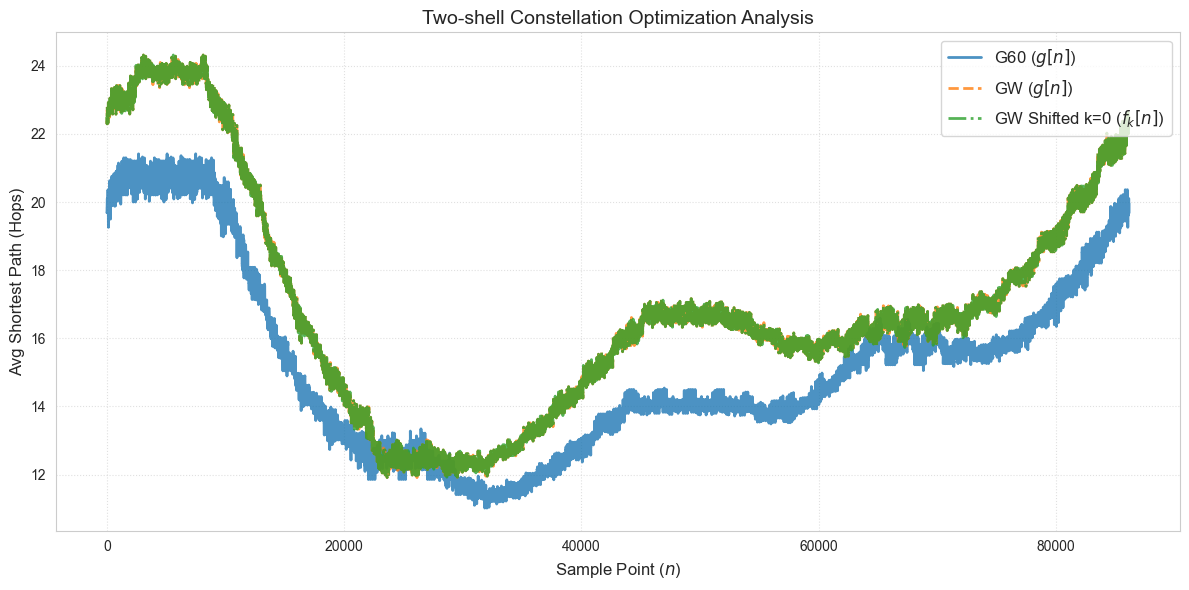

In [9]:
# 假设 k = 100
# we need know that all the data should process in the origin

k_test = 0

# 1. 获取偏移后的 GW 序列
GW_FUNCTIION_k = get_shifted_sequence(GW_FUNCTIION, k_test)

# 2. 如果你想的话，顺便把包络线 h_k[n] 也算出来
# np.minimum 会逐点比较取最小值
h_k_sequence = np.minimum(np.asarray(G60_FUNCTIION), np.asarray(GW_FUNCTIION_k))

# 3. 构造字典并传入绘图函数
data_to_plot = {
    "G60 ($g[n]$)": G60_FUNCTIION,
 "GW ($g[n]$)": GW_FUNCTIION,

    f"GW Shifted k={k_test} ($f_k[n]$)": GW_FUNCTIION_k,

}

plot_multiple_sequences(data_to_plot, title="Two-shell Constellation Optimization Analysis")


In [12]:
# we write the above offset chart to a book,just a test
# write the arrary to the book sheet
# attention ,the function is {to_origin}
# we write the baseline to the origin ,that is k=0
#
# 1. 构造包含 X轴(k) 和 Y轴(score) 的字典，并转为 DataFrame
# 假设 score_array 已经由上一步的 find_optimal_shift 计算得出

N = len(G60_FUNCTIION)
gw_g60_and_offsetgw_to_export = pd.DataFrame({
    "time": np.arange(N),       # 第一列：偏移量 k (0 到 N-1)
    "G60": G60_FUNCTIION,       # 第二列：对应的平均跳数 h_k[n]
      "GW": GW_FUNCTIION,       # 第二列：对应的平均跳数 h_k[n]
      "gw_offset": GW_FUNCTIION_k,       # 第二列：对应的平均跳数 h_k[n]
})

# 2. 调用你自定义的写入函数
# 你可以自定义 book 和 sheet 的名字，比如存到 "Optimization" 工作簿的 "ScoreData" 表中
try:
    csv2origin.to_origin(gw_g60_and_offsetgw_to_export, book="test", sheet="test", clear=True)
    print("数据已成功写入 Origin！工作簿: Optimization, 工作表: ScoreData")
except Exception as e:
    print(f"写入 Origin 时发生错误: {e}")

#so here ,gw_offset us


数据已成功写入 Origin！工作簿: Optimization, 工作表: ScoreData


正在遍历 k 从 0 到 86164...
计算完成！
最优偏移量 k_opt = 57940
对应的最小平均跳数 = 13.6664


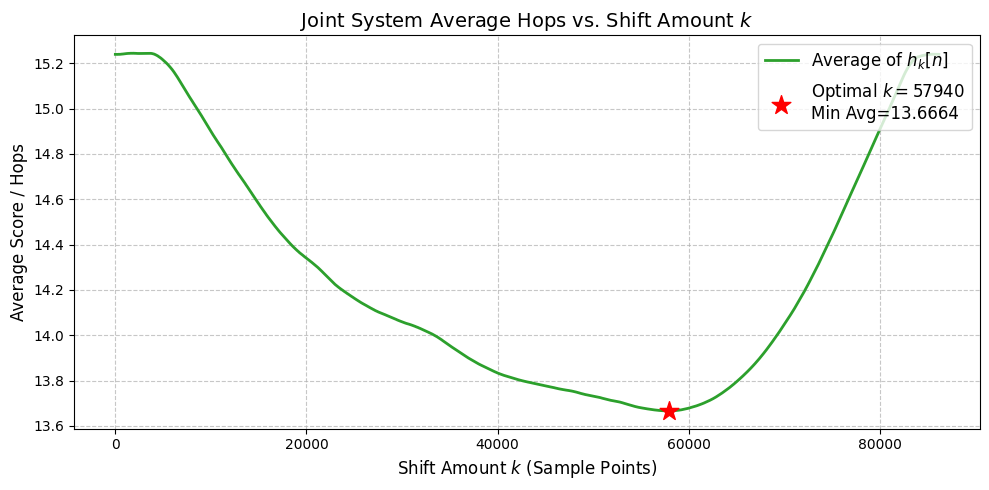

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def find_optimal_shift(g_seq, f_seq):
    """
    遍历所有的 k，计算 h_k[n] 的平均值，并找出最优的 k。

    参数:
    g_seq: G60 的序列 g[n]
    f_seq: GW 的序列 f[n]

    返回:
    optimal_k: 使得平均跳数最小的偏移量 k
    avg_h_k_array: 记录了每个 k 对应的 h_k[n] 平均值的数组
    """
    g_array = np.asarray(g_seq)
    f_array = np.asarray(f_seq)

    N = len(g_array)
    if len(f_array) != N:
        raise ValueError("G60 和 GW 的序列长度必须一致！")

    avg_h_k_list = []

    print(f"正在遍历 k 从 0 到 {N-1}...")

    # 遍历所有的 k
    for k in range(N):
        # 1. 获取偏移后的 f_k[n]
        f_k = np.roll(f_array, k)

        # 2. 取逐点最小值 h_k[n] = min(g[n], f_k[n])
        h_k = np.minimum(g_array, f_k)

        # 3. 计算当前 h_k[n] 的平均值
        current_avg = np.mean(h_k)

        # 4. 记录结果
        avg_h_k_list.append(current_avg)

    avg_h_k_array = np.array(avg_h_k_list)

    # 找出平均值最小的 k
    optimal_k = np.argmin(avg_h_k_array)
    min_avg_value = avg_h_k_array[optimal_k]

    print(f"计算完成！")
    print(f"最优偏移量 k_opt = {optimal_k}")
    print(f"对应的最小平均跳数 = {min_avg_value:.4f}")

    return optimal_k, avg_h_k_array, min_avg_value

def plot_score_vs_k(avg_h_k_array, optimal_k, min_avg_value):
    """
    绘制 h_k[n] 的平均值随着 k 的变化曲线，并标出最低点。
    """
    N = len(avg_h_k_array)
    x_axis = np.arange(N)

    plt.figure(figsize=(10, 5))

    # 绘制随 k 变化的曲线
    plt.plot(x_axis, avg_h_k_array, label='Average of $h_k[n]$', color='#2ca02c', linewidth=2)

    # 突出显示最优点 (红星)
    plt.scatter(optimal_k, min_avg_value, color='red', marker='*', s=200, zorder=5,
                label=f'Optimal $k={optimal_k}$\nMin Avg={min_avg_value:.4f}')

    # 设置图表元素
    plt.title("Joint System Average Hops vs. Shift Amount $k$", fontsize=14)
    plt.xlabel("Shift Amount $k$ (Sample Points)", fontsize=12)
    plt.ylabel("Average Score / Hops", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(loc="upper right", fontsize=12)

    plt.tight_layout()
    plt.show()

# ================= 调用执行 =================
# 1. 运行遍历计算
best_k, score_array, best_score = find_optimal_shift(G60_FUNCTIION, GW_FUNCTIION)

# 2. 绘制评分随 k 的变化图
plot_score_vs_k(score_array, best_k, best_score)

In [ ]:
#

In [ ]:
# write the arrary to the book sheet
# attention ,the function
# to_origin
import pandas as pd
import numpy as np

# 1. 构造包含 X轴(k) 和 Y轴(score) 的字典，并转为 DataFrame
# 假设 score_array 已经由上一步的 find_optimal_shift 计算得出

N = len(score_array)
df_to_export = pd.DataFrame({
    "Shift_k": np.arange(N),       # 第一列：偏移量 k (0 到 N-1)
    "Avg_Score": score_array       # 第二列：对应的平均跳数 h_k[n]
})

# 2. 调用你自定义的写入函数
# 你可以自定义 book 和 sheet 的名字，比如存到 "Optimization" 工作簿的 "ScoreData" 表中
try:
    csv2origin.to_origin(df_to_export, book="Optimization", sheet="ScoreData", clear=True)
    print("数据已成功写入 Origin！工作簿: Optimization, 工作表: ScoreData")
except Exception as e:
    print(f"写入 Origin 时发生错误: {e}")



### we write the h[n] to the origin

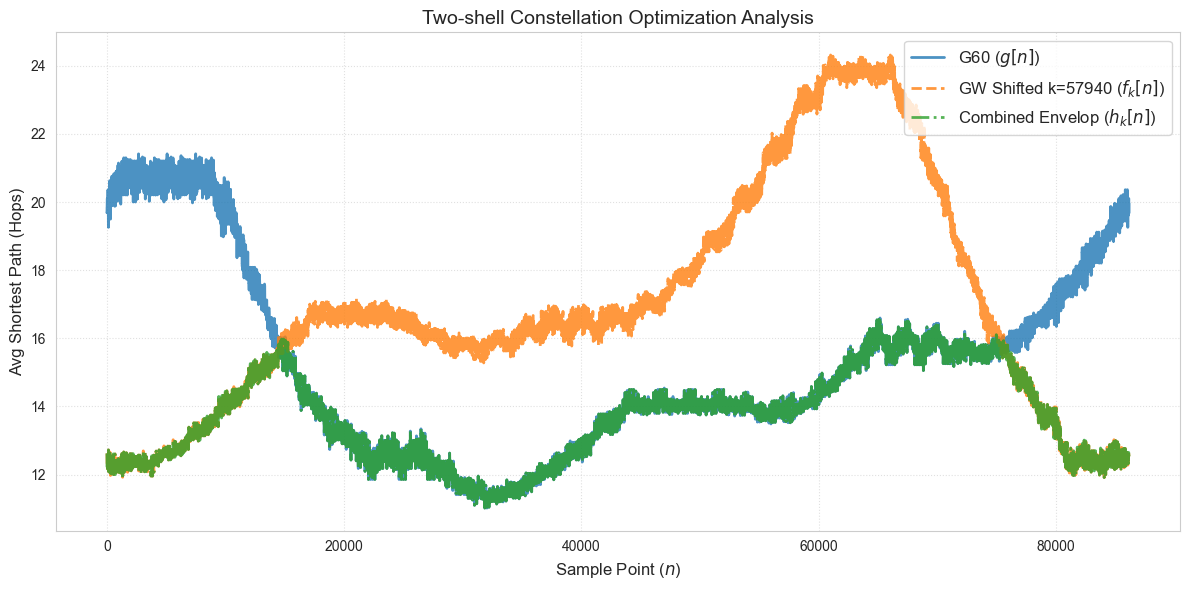

WSheet: [treeline]treeline

In [24]:
# 假设 k = 100
# we need know that all the data should process in the origin

k_test = 57940

# 1. 获取偏移后的 GW 序列
GW_FUNCTIION_k = get_shifted_sequence(GW_FUNCTIION, k_test)

# 2. 如果你想的话，顺便把包络线 h_k[n] 也算出来
# np.minimum 会逐点比较取最小值
h_k_sequence = np.minimum(np.asarray(G60_FUNCTIION), np.asarray(GW_FUNCTIION_k))

# 3. 构造字典并传入绘图函数
data_to_plot = {
    "G60 ($g[n]$)": G60_FUNCTIION,

    f"GW Shifted k={k_test} ($f_k[n]$)": GW_FUNCTIION_k,
    "Combined Envelop ($h_k[n]$)": h_k_sequence  # 这个包络线就是你公式里的 Score 来源
}

plot_multiple_sequences(data_to_plot, title="Two-shell Constellation Optimization Analysis")

N = len(GW_FUNCTIION_k)
GW_FUNCTIION_k_to_export = pd.DataFrame({
    "time": np.arange(N),       # 第一列：偏移量 k (0 到 N-1)
    "GW_FUNCTIION_k": GW_FUNCTIION_k,       # 第二列：对应的平均跳数 h_k[n]
        "G60_FUNCTIION": G60_FUNCTIION,       # 第二列：对应的平均跳数 h_k[n]

        "hn": h_k_sequence       # 第二列：对应的平均跳数 h_k[n]
})



csv2origin.to_origin(GW_FUNCTIION_k_to_export, book="treeline", sheet="treeline", clear=True)

## and we read the GW_FUNCTIION_k to the origin


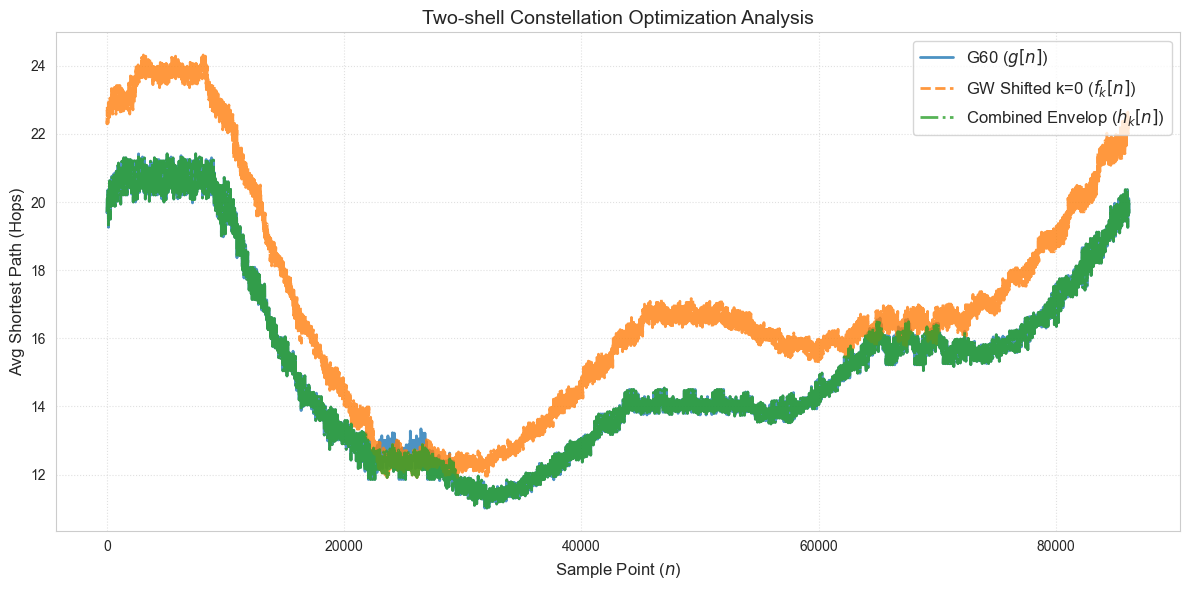

WSheet: [G60GWbaseline]G60GWbaseline

In [25]:
# here is the baseline
# 假设 k = 0
# we need know that all the data should process in the origin

k_test = 0

# 1. 获取偏移后的 GW 序列
GW_FUNCTIION_k = get_shifted_sequence(GW_FUNCTIION, k_test)

# 2. 如果你想的话，顺便把包络线 h_k[n] 也算出来
# np.minimum 会逐点比较取最小值
h_k_sequence = np.minimum(np.asarray(G60_FUNCTIION), np.asarray(GW_FUNCTIION_k))

# 3. 构造字典并传入绘图函数
data_to_plot = {
    "G60 ($g[n]$)": G60_FUNCTIION,

    f"GW Shifted k={k_test} ($f_k[n]$)": GW_FUNCTIION_k,
    "Combined Envelop ($h_k[n]$)": h_k_sequence  # 这个包络线就是你公式里的 Score 来源
}

plot_multiple_sequences(data_to_plot, title="Two-shell Constellation Optimization Analysis")

N = len(GW_FUNCTIION_k)
GW_FUNCTIION_k_to_export = pd.DataFrame({
    "time": np.arange(N),       # 第一列：偏移量 k (0 到 N-1)
    "GW_FUNCTIION_k": GW_FUNCTIION_k,       # 第二列：对应的平均跳数 h_k[n]
        "G60_FUNCTIION": G60_FUNCTIION,       # 第二列：对应的平均跳数 h_k[n]

        "hn": h_k_sequence       # 第二列：对应的平均跳数 h_k[n]
})



csv2origin.to_origin(GW_FUNCTIION_k_to_export, book="G60GWbaseline", sheet="G60GWbaseline", clear=True)

## and we read the GW_FUNCTIION_k to the origin


In [26]:
## here we have the k=0 and k=k* data, we need process the data,


# 这里的函数，是为了求解上述功能块的 MergeData的各项数值
TARGET_BOOK = "G60GWbaseline"
sheetname   = "G60GWbaseline"

wks = op.find_sheet('w', f'[{TARGET_BOOK}]{sheetname}')

if wks is None:
    raise RuntimeError("找不到指定工作表")

mainline = wks.to_df(head='L')

G60_line=mainline["G60_FUNCTIION"]

GW_line = mainline["GW_FUNCTIION_k"]

baseline = mainline["hn"]


TARGET_BOOK = "treeline"
sheetname   = "treeline"

wks = op.find_sheet('w', f'[{TARGET_BOOK}]{sheetname}')

if wks is None:
    raise RuntimeError("找不到指定工作表")

mainline = wks.to_df(head='L')


optimal = mainline["hn"]


===== Average Metrics =====
G60 only                   : 15.2520
GW only                    : 16.9578
Aligned dual-shell baseline: 15.2398
Optimized dual-shell       : 13.6664

===== Improvements =====
Optimal vs aligned baseline: 10.32%
Optimal vs G60 only        : 10.40%
Optimal vs GW only         : 19.41%


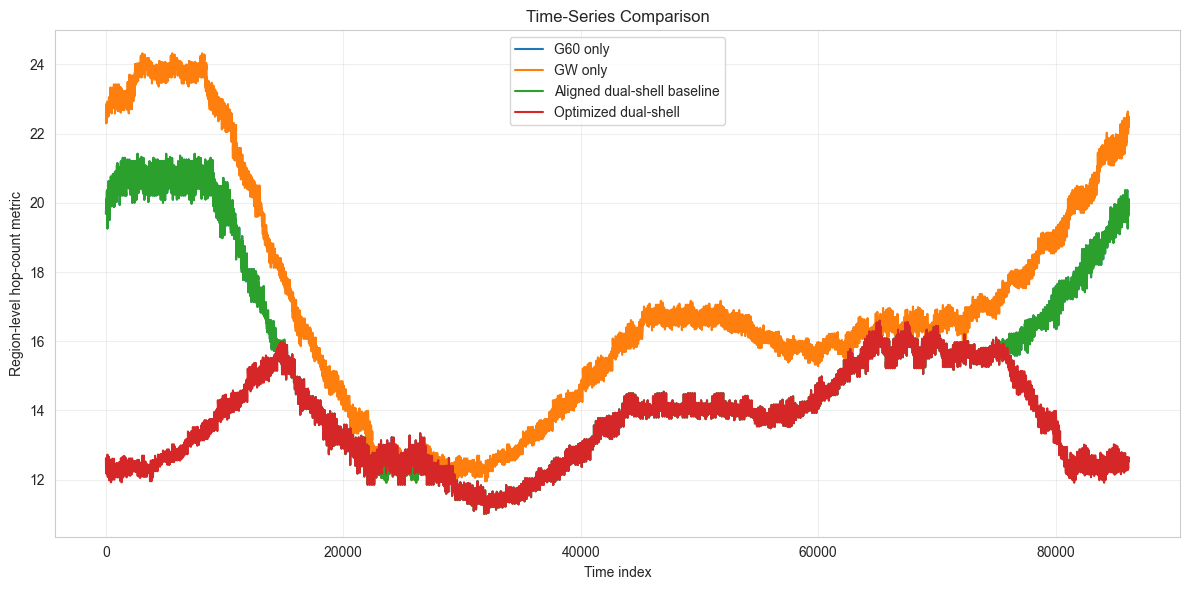

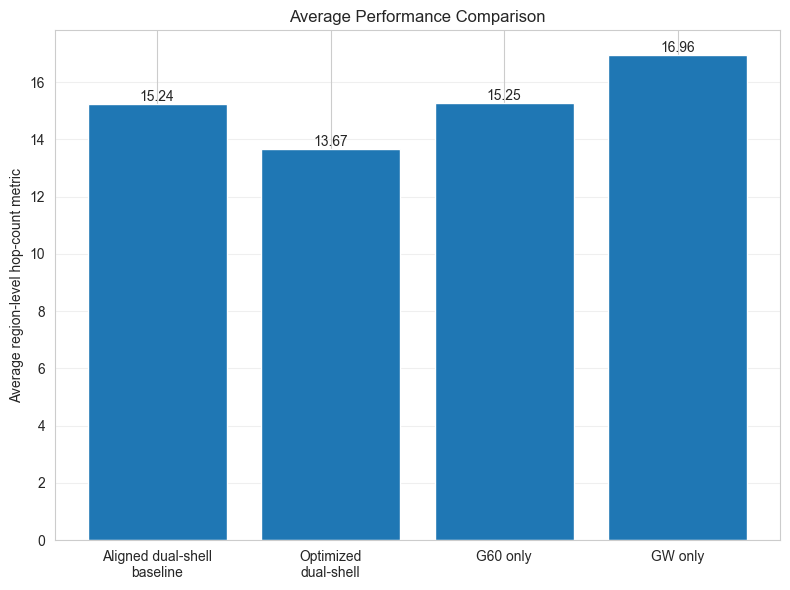

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. 读取 baseline 工作表
# =========================
TARGET_BOOK = "G60GWbaseline"
sheetname   = "G60GWbaseline"

wks = op.find_sheet('w', f'[{TARGET_BOOK}]{sheetname}')
if wks is None:
    raise RuntimeError(f"找不到指定工作表: [{TARGET_BOOK}]{sheetname}")

df_base = wks.to_df(head='L')

# 这里按你当前的列名来取
G60_line = np.asarray(df_base["G60_FUNCTIION"], dtype=float)
GW_line = np.asarray(df_base["GW_FUNCTIION_k"], dtype=float)
baseline_line = np.asarray(df_base["hn"], dtype=float)   # k=0 的 h_k[n]

# =========================
# 2. 读取 optimal 工作表
# =========================
TARGET_BOOK = "treeline"
sheetname   = "treeline"

wks = op.find_sheet('w', f'[{TARGET_BOOK}]{sheetname}')
if wks is None:
    raise RuntimeError(f"找不到指定工作表: [{TARGET_BOOK}]{sheetname}")

df_opt = wks.to_df(head='L')
optimal_line = np.asarray(df_opt["hn"], dtype=float)     # k=k* 的 h_k[n]

# =========================
# 3. 长度检查
# =========================
N = len(G60_line)
if not (len(GW_line) == N and len(baseline_line) == N and len(optimal_line) == N):
    raise ValueError(
        f"四条序列长度不一致: "
        f"G60={len(G60_line)}, GW={len(GW_line)}, "
        f"baseline={len(baseline_line)}, optimal={len(optimal_line)}"
    )

time = np.arange(N)

# =========================
# 4. 计算平均值
# =========================
g60_mean = float(np.mean(G60_line))
gw_mean = float(np.mean(GW_line))
baseline_mean = float(np.mean(baseline_line))
optimal_mean = float(np.mean(optimal_line))

def improvement(old, new):
    return (old - new) / old * 100.0

imp_vs_baseline = improvement(baseline_mean, optimal_mean)
imp_vs_g60 = improvement(g60_mean, optimal_mean)
imp_vs_gw = improvement(gw_mean, optimal_mean)

print("===== Average Metrics =====")
print(f"G60 only                   : {g60_mean:.4f}")
print(f"GW only                    : {gw_mean:.4f}")
print(f"Aligned dual-shell baseline: {baseline_mean:.4f}")
print(f"Optimized dual-shell       : {optimal_mean:.4f}")

print("\n===== Improvements =====")
print(f"Optimal vs aligned baseline: {imp_vs_baseline:.2f}%")
print(f"Optimal vs G60 only        : {imp_vs_g60:.2f}%")
print(f"Optimal vs GW only         : {imp_vs_gw:.2f}%")

# =========================
# 5. 绘制时序曲线图
# =========================
plt.figure(figsize=(12, 6))
plt.plot(time, G60_line, label="G60 only")
plt.plot(time, GW_line, label="GW only")
plt.plot(time, baseline_line, label="Aligned dual-shell baseline")
plt.plot(time, optimal_line, label="Optimized dual-shell")

plt.xlabel("Time index")
plt.ylabel("Region-level hop-count metric")
plt.title("Time-Series Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =========================
# 6. 绘制柱状图
# =========================
labels = [
    "Aligned dual-shell\nbaseline",
    "Optimized\ndual-shell",
    "G60 only",
    "GW only"
]
values = [baseline_mean, optimal_mean, g60_mean, gw_mean]

plt.figure(figsize=(8, 6))
bars = plt.bar(labels, values)

plt.ylabel("Average region-level hop-count metric")
plt.title("Average Performance Comparison")
plt.grid(True, axis='y', alpha=0.3)

# 在柱子顶端标数值
for bar, val in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{val:.2f}",
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()



## write to the origin




In [29]:

# 1. 计算四个均值
g60_mean = float(np.mean(G60_line))
gw_mean = float(np.mean(GW_line))
baseline_mean = float(np.mean(baseline_line))
optimal_mean = float(np.mean(optimal_line))

# 2. 构造用于导出到 Origin 的表
# 修正：用列表包裹标量值
mean_values_to_export = pd.DataFrame({
    "baseline_mean": [baseline_mean],
    "optimal_mean":  [optimal_mean],
    "g60_mean":      [g60_mean],
    "gw_mean":       [gw_mean],
})







csv2origin.to_origin(mean_values_to_export, book="four", sheet="MeanValues", clear=True)



    # print("四个均值已成功写入 Origin！工作簿: FourBarComparison, 工作表: MeanValues")


WSheet: [four]MeanValues

13.666368797232447

In [ ]:
import math

def calculate_arcsin_term(alpha, theta0):
    """
    计算 delta = arcsin( sin(alpha) / sin(theta0) )

    参数:
    alpha  : 弧度 (radians)
    theta0 : 弧度 (radians)

    返回:
    float : 计算结果 (弧度)
    """
    # 1. 计算分母 sin(theta0)
    sin_theta = math.sin(theta0)

    # 防止分母为 0
    if abs(sin_theta) < 1e-9:
        raise ValueError("theta0 不能为 0，会导致除零错误")

    # 2. 计算中间比值 ratio
    # ratio = sin(alpha) / sin(theta0)
    ratio = math.sin(alpha) / sin_theta

    # 3. 关键：检查 arcsin 的定义域
    # arcsin 的输入必须在 [-1, 1] 之间
    if ratio > 1 or ratio < -1:
        error_msg = (
            f"数学错误: sin(alpha)/sin(theta0) = {ratio:.4f}，超出了 [-1, 1] 的范围。\n"
            f"这意味着 alpha ({math.degrees(alpha):.2f}°) 的正弦值比 theta0 ({math.degrees(theta0):.2f}°) 的正弦值还大。\n"
            "在几何上，这通常构不成三角形。"
        )
        raise ValueError(error_msg)

    # 4. 计算 arcsin
    result = math.asin(ratio)

    return result

# --- 测试代码 (使用你上一轮的数据) ---
try:
    # 定义输入 (角度转弧度)
    a_deg = 10   # alpha
    t_deg = 45   # theta0

    a_rad = math.radians(a_deg)
    t_rad = math.radians(t_deg)

    # 调用函数
    delta_rad = calculate_arcsin_term(a_rad, t_rad)

    # 输出结果
    print(f"输入: alpha={a_deg}°, theta0={t_deg}°")
    print(f"计算出的中间比值 (ratio): {math.sin(a_rad)/math.sin(t_rad):.4f}")
    print(f"结果 (弧度): {delta_rad:.4f}")
    print(f"结果 (角度): {math.degrees(delta_rad):.4f}°")
    # 这里应该输出 20.32°，正是导致你之前算出负数的原因

except ValueError as e:
    print(e)

## 多日最短路径数据

这一章节，我们主要是将多日的数据进行转换，转为恒星日数据，然后单纯存入到orgin里，
注意，是一个星座一个origin


In [4]:
FIGURE_DIR

NameError: name 'FIGURE_DIR' is not defined

In [5]:
# 恒星日
# 时间是86164

import numpy as np
import pandas as pd
from datetime import datetime, timedelta
from pathlib import Path

# ================= 配置参数 =================
FIGURE_DIR_BASE = FIGURE_DIR   # 你的总目录 Path 对象

BASE_DATE = datetime(2025, 1, 6)
START_DAY = 6
END_DAY = 29
YEAR = 2025
MONTH = 1

TOTAL_START = 0
TOTAL_END = 86400
CHUNK_SIZE = 10000

# 恒星日长度（秒）
SIDEREAL_DAY = 86164.0905
SIDEREAL_LEN = 86164   # 若为1秒采样，通常取整数长度

# 文件名前缀
FILE_PREFIX = "avgspath_g0_4_baseline"
# FILE_PREFIX = "city1"

current_book_name = 'Book2'
# ================= 辅助函数 =================
def _make_nan_rows_like(df: pd.DataFrame, n: int) -> pd.DataFrame:
    """生成 n 行 NaN，列与 df 一致"""
    if n <= 0:
        return pd.DataFrame(columns=df.columns)
    return pd.DataFrame({c: [np.nan] * n for c in df.columns})

def load_one_day_raw(base_dir: Path, date_obj: datetime) -> pd.DataFrame | None:
    """读取某一天的所有 chunk 原始数据并合并"""
    date_str = date_obj.strftime("%Y%m%d")
    day_folder = base_dir / f"day_{date_str}" / "path"

    if not day_folder.exists():
        print(f"[Warning] 文件夹不存在: {day_folder}")
        return None

    all_dfs = []
    for batch_start in range(TOTAL_START, TOTAL_END, CHUNK_SIZE):
        batch_end = min(batch_start + CHUNK_SIZE, TOTAL_END)
        filename = f"{FILE_PREFIX}_{batch_start}_to_{batch_end}.csv"
        csv_path = day_folder / filename
        if csv_path.exists():
            try:
                df = pd.read_csv(csv_path)
                all_dfs.append(df)
            except Exception as e:
                print(f"[Error] 读取失败: {csv_path} | {e}")

    if not all_dfs:
        print(f"[Warning] {date_str} 无可读数据")
        return None

    day_df = pd.concat(all_dfs, ignore_index=True)

    # 按第一列排序，默认第一列为时间列
    if len(day_df.columns) > 0:
        day_df.sort_values(by=day_df.columns[0], ascending=True, inplace=True)
        day_df.reset_index(drop=True, inplace=True)

    return day_df

# ================= Step 1: 读取全部原始太阳日数据 =================
all_days = []
date_list = []

for day in range(START_DAY, END_DAY + 1):
    date_obj = datetime(YEAR, MONTH, day)
    date_str = date_obj.strftime("%Y%m%d")

    print(f"\n读取原始太阳日数据: {date_str}")
    day_df = load_one_day_raw(FIGURE_DIR_BASE, date_obj)

    if day_df is None:
        continue

    # 增加全局时间索引列，后面切片更方便
    # 先保留原始列，稍后整体拼接后再统一加 global_second
    all_days.append(day_df)
    date_list.append(date_obj)

if not all_days:
    raise RuntimeError("没有读取到任何原始数据。")

# 以第一天列结构为基准
template_df = all_days[0].copy()

# ================= Step 2: 拼接成连续总序列 =================
continuous_df = pd.concat(all_days, ignore_index=True)

# 原始时间列重建为全局秒索引
time_col = continuous_df.columns[0]
continuous_df[time_col] = np.arange(len(continuous_df), dtype=int)

print(f"\n连续原始总长度: {len(continuous_df)} 行")

# ================= Step 3: 按恒星日切窗 =================
num_sidereal_days = len(date_list)

for k in range(num_sidereal_days):
    current_date = date_list[k]
    date_str = current_date.strftime("%Y%m%d")
    sheet_num = 1 + (current_date - BASE_DATE).days
    # current_book_name = f"Book{book_num}"
    sheetname = f"SiderealDay{sheet_num}"

    # 第 k 个恒星日窗口的起点
    start_idx = int(round(k * SIDEREAL_DAY))
    end_idx = start_idx + SIDEREAL_LEN

    print(f"\n{'='*60}")
    print(f"日期: {date_str} | Book: {current_book_name}")
    print(f"恒星日起点: {start_idx}")
    print(f"恒星日终点: {end_idx - 1}")
    print(f"窗口长度: {SIDEREAL_LEN}")
    print(f"{'='*60}")

    if start_idx >= len(continuous_df):
        print(f"[Warning] 起点越界，跳过 {date_str}")
        continue

    sidereal_df = continuous_df.iloc[start_idx:end_idx].copy()

    # 不够长度则补 NaN
    if len(sidereal_df) < SIDEREAL_LEN:
        pad = _make_nan_rows_like(template_df, SIDEREAL_LEN - len(sidereal_df))
        sidereal_df = pd.concat([sidereal_df, pad], ignore_index=True)

    # 重置窗口内时间轴为 0 ... SIDEREAL_LEN-1
    sidereal_df[time_col] = np.arange(len(sidereal_df), dtype=int)

    # 保存路径
    save_dir = FIGURE_DIR_BASE / f"day_{date_str}" / "path"
    save_dir.mkdir(parents=True, exist_ok=True)

    out_name = f"{FILE_PREFIX}_ALL_{date_str}_SIDEREAL_DAY.csv"
    out_path = save_dir / out_name
    sidereal_df.to_csv(out_path, index=False)

    print(f">> 已保存: {out_name} | Rows: {len(sidereal_df)}")

    # 导入 Origin
    try:
        csv2origin.csv_to_origin(
            out_path,
            book=current_book_name,
            sheet=sheetname,
            clear=True
        )
        print(f">> 导入 Origin 成功: {current_book_name}")
    except Exception as e:
        print(f"[Warn] Origin 导入失败: {e}")

print("\n全部恒星日提取完成。")


读取原始太阳日数据: 20250106

读取原始太阳日数据: 20250107

读取原始太阳日数据: 20250108

读取原始太阳日数据: 20250109

读取原始太阳日数据: 20250110

读取原始太阳日数据: 20250111

读取原始太阳日数据: 20250112

读取原始太阳日数据: 20250113

读取原始太阳日数据: 20250114

读取原始太阳日数据: 20250115

读取原始太阳日数据: 20250116

读取原始太阳日数据: 20250117

读取原始太阳日数据: 20250118

读取原始太阳日数据: 20250119

读取原始太阳日数据: 20250120

读取原始太阳日数据: 20250121

读取原始太阳日数据: 20250122

读取原始太阳日数据: 20250123

读取原始太阳日数据: 20250124

读取原始太阳日数据: 20250125

读取原始太阳日数据: 20250126

读取原始太阳日数据: 20250127

读取原始太阳日数据: 20250128

读取原始太阳日数据: 20250129

连续原始总长度: 2073600 行

日期: 20250106 | Book: Book2
恒星日起点: 0
恒星日终点: 86163
窗口长度: 86164
>> 已保存: avgspath_g0_4_baseline_ALL_20250106_SIDEREAL_DAY.csv | Rows: 86164
>> 导入 Origin 成功: Book2

日期: 20250107 | Book: Book2
恒星日起点: 86164
恒星日终点: 172327
窗口长度: 86164
>> 已保存: avgspath_g0_4_baseline_ALL_20250107_SIDEREAL_DAY.csv | Rows: 86164
>> 导入 Origin 成功: Book2

日期: 20250108 | Book: Book2
恒星日起点: 172328
恒星日终点: 258491
窗口长度: 86164
>> 已保存: avgspath_g0_4_baseline_ALL_20250108_SIDEREAL_DAY.csv | Rows: 86164
>> 导入 Or

In [6]:
#下面是暂时画图而已。
# ================= Step 4: 利用 continuous_df 生成 MergedDays 并写入 Origin =================
# 不修改原来的主代码
# 直接复用: continuous_df, date_list, current_book_name, BASE_DATE, SIDEREAL_DAY, SIDEREAL_LEN

import numpy as np
import pandas as pd

# 选择要合并的数值列
# 默认取第二列作为目标值列
value_col = continuous_df.columns[1]

print(f"\n开始生成 MergedDays，使用数值列: {value_col}")

merged_dict = {}
merged_dict["time"] = np.arange(SIDEREAL_LEN, dtype=int)

for k in range(len(date_list)):
    current_date = date_list[k]
    sheet_num = 1 + (current_date - BASE_DATE).days
    col_name = f"Day{sheet_num:02d}"

    start_idx = int(round(k * SIDEREAL_DAY))
    end_idx = start_idx + SIDEREAL_LEN

    if start_idx >= len(continuous_df):
        print(f"[Warning] {col_name} 起点越界，跳过")
        continue

    y = continuous_df.iloc[start_idx:end_idx][value_col].to_numpy()

    # 如果末尾不够长，补 NaN
    if len(y) < SIDEREAL_LEN:
        y = np.pad(y, (0, SIDEREAL_LEN - len(y)), mode="constant", constant_values=np.nan)

    merged_dict[col_name] = y

merged_df = pd.DataFrame(merged_dict)

print(f"MergedDays 数据形状: {merged_df.shape}")

# 写入同一个 book 的新 sheet
try:
    csv2origin.to_origin(merged_df, book=current_book_name, sheet="MergedDays", clear=True)
    print(f"数据已成功写入 Origin！工作簿: {current_book_name}, 工作表: MergedDays")
except Exception as e:
    print(f"写入 Origin 时发生错误: {e}")


开始生成 MergedDays，使用数值列: avg_shortest_path
MergedDays 数据形状: (86164, 25)
数据已成功写入 Origin！工作簿: Book2, 工作表: MergedDays


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# =========================================================
# 你前面的代码已经有这些变量了，这里直接复用：
# continuous_df
# date_list
# BASE_DATE
# SIDEREAL_DAY
# SIDEREAL_LEN
# =========================================================

# -------- 1. 指定要画的数值列 ----------
# 如果你的列名就是 avg_shortest_path，直接写这个
value_col = "avg_shortest_path"

# 如果不确定列名，可以先 print 一下：
print("continuous_df columns:", list(continuous_df.columns))

# 如果 value_col 不存在，就自动取第二列
if value_col not in continuous_df.columns:
    value_col = continuous_df.columns[1]
    print(f"[Info] 未找到 'avg_shortest_path'，改用列: {value_col}")

# -------- 2. 从 continuous_df 中切出所有恒星日曲线 ----------
sidereal_curves = []
used_dates = []

num_sidereal_days = len(date_list)

for k in range(num_sidereal_days):
    current_date = date_list[k]
    date_str = current_date.strftime("%Y%m%d")

    start_idx = int(round(k * SIDEREAL_DAY))
    end_idx = start_idx + SIDEREAL_LEN

    if start_idx >= len(continuous_df):
        print(f"[Warning] {date_str} 起点越界，跳过")
        continue

    y = continuous_df.iloc[start_idx:end_idx][value_col].to_numpy()

    # 长度不足则补 NaN
    if len(y) < SIDEREAL_LEN:
        y = np.pad(y, (0, SIDEREAL_LEN - len(y)), mode="constant", constant_values=np.nan)

    sidereal_curves.append(y)
    used_dates.append(date_str)

# 转成矩阵：shape = (n_days, SIDEREAL_LEN)
sidereal_mat = np.array(sidereal_curves)

# 再转置成更适合按时间统计的形式：shape = (SIDEREAL_LEN, n_days)
sidereal_mat_t = sidereal_mat.T

print("sidereal_mat_t shape =", sidereal_mat_t.shape)  # (86164, 24) 之类

# -------- 3. 统计 mean/std ----------
mean_curve = np.nanmean(sidereal_mat_t, axis=1)
std_curve  = np.nanstd(sidereal_mat_t, axis=1)

upper = mean_curve + std_curve
lower = mean_curve - std_curve

x = np.arange(SIDEREAL_LEN)

# -------- 4. 绘图 ----------
fig, ax = plt.subplots(figsize=(11, 5), dpi=300)

# 标准差阴影带
ax.fill_between(x, lower, upper, alpha=0.25, label="Mean ± 1 STD")

# 均值曲线
ax.plot(x, mean_curve, linewidth=2.2, label="Mean")

ax.set_xlabel("Time (s)")
ax.set_ylabel(value_col)
ax.set_xlim(0, SIDEREAL_LEN - 1)
ax.legend(frameon=False)

plt.tight_layout()

# -------- 5. 保存 ----------
save_fig = Path("sidereal_mean_std_band.png")
plt.savefig(save_fig, dpi=300, bbox_inches="tight")
plt.show()

print(f">> 图已保存: {save_fig.resolve()}")

NameError: name 'continuous_df' is not defined

## 附录部分的证明

### cdf曲线绘制

In [3]:
FIGURE_DIR = Path(r"C:\usrspace\mywork\data_paper2\paper_need_data\appdix")
out_name = f"all_range_hops_valid.csv"
out_path = FIGURE_DIR / out_name

current_book_name='Book1'

sheetname = 'orbitalpair'
# 导入 Origin

csv2origin.csv_to_origin(
out_path,
book=current_book_name,
sheet=sheetname,
clear=True
)

WSheet: [Book1]orbitalpair

In [ ]:
# ================= 配置参数 =================
DATA_DIR = Path(r"C:\usrspace\mywork\data_paper2")
BASEDIR = DATA_DIR / "visibile_data"

VERSION1 = 'differentraan'
DEFAULT_TTB_VALUES = [15, 55, 95, 135, 175, 215, 255, 295, 325,181]


# 4. 其他数据参数
start_ts = 0
end_ts = 86400
TOTAL_START = start_ts
TOTAL_END = end_ts
CHUNK_SIZE = 10000

book_num=1
# ================= 主循环 =================
for baseraan in DEFAULT_TTB_VALUES:
    # --- A. 计算日期和对应的 Book Name ---
    # 构造当前日期的 datetime 对象


    version2 = f"baseRaan_{baseraan}"
    FIGURE_DIR = BASEDIR / VERSION1 / version2/"path"

    book_num = 1 + book_num
    current_book_name = f"Book{book_num}"



    print(f"\n{'='*60}")

    print(f"对应 Origin Book: {current_book_name}") # 这里会显示 Book4, Book5...
    print(f"读取路径: {FIGURE_DIR}")
    print(f"{'='*60}")

    # 检查文件夹是否存在
    if not FIGURE_DIR.exists():
        print(f"[Warning] 文件夹不存在，跳过: {FIGURE_DIR}")
        continue

    # ================= 内部逻辑：合并分片 =================
    all_data_frames = []

    for batch_start in range(TOTAL_START, TOTAL_END, CHUNK_SIZE):
        batch_end = min(batch_start + CHUNK_SIZE, TOTAL_END)
        filename = f"avgspath_g0_4_baseline_{batch_start}_to_{batch_end}.csv"
        csv1_path = FIGURE_DIR / filename

        if csv1_path.exists():
            try:
                df = pd.read_csv(csv1_path)
                all_data_frames.append(df)
            except Exception as e:
                print(f"  [Error] 读取 {filename} 失败: {e}")
        # else:
            # print(f"  [Info] 分片缺失: {filename}") (可选：减少刷屏可以注释掉)

    # ================= 保存与导入 =================
    if all_data_frames:
        print(f"  >> 合并 {len(all_data_frames)} 个文件...")
        merged_df = pd.concat(all_data_frames, ignore_index=True)

        # 排序
        time_col_name = merged_df.columns[0]
        merged_df.sort_values(by=time_col_name, ascending=True, inplace=True)

        # 保存合并版 CSV
        merged_filename = f"avgspath_g0_4_baseline_ALL_{baseraan}.csv"

        merged_csv_path = FIGURE_DIR / merged_filename
        merged_df.to_csv(merged_csv_path, index=False)
        print(f"  >> CSV 已保存: {merged_filename}")

        # 导入 Origin
        print(f"  >> 正在导入到 {current_book_name} ...")
        try:
            csv2origin.csv_to_origin(
                merged_csv_path,
                book=current_book_name,  # 动态计算的 BookName
                sheet="MergedData",
                clear=True
            )
            print(f"  >> {current_book_name} 导入成功。")
        except Exception as e:
            print(f"  [Error] Origin 导入失败: {e}")

    else:
        print(f"   。")

print("\n全部完成。")

In [ ]:

from math import inf

DEFAULT_TTB_VALUES = [15, 55, 95, 135, 175, 215, 255, 295, 325,181]


BOOKname = 'Book1'
sheet_name = 'MergedData'
wks = csv2origin.read_book_sheet(BOOKname,sheet_name)
gx = wks.to_df(head='L')

g_data = gx.iloc[:, 1].values # 取第一列数据
results = []


best_score = 20
min_score_std = inf
best_id = None
best_std_id = None

# ================= 主循环 =================
for bookeid in range(len(DEFAULT_TTB_VALUES)):
    BOOKname = "Book" + str(bookeid+2)
    sheet_name = 'MergedData'
    wks = csv2origin.read_book_sheet(BOOKname,sheet_name)

    df = wks.to_df(head='L')

    f_data = df.iloc[:, 1].values # 取第一列数据
    h_curve = np.minimum(g_data, f_data)
        # 计算平均有效值 (Score A)
    score_a = np.mean(h_curve)
    score_std = np.std(h_curve)
    print(f"bookid{bookeid}:{np.mean(f_data)}")

    results.append((bookeid, score_a,score_std))
    if score_a < best_score:
        best_score = score_a
        best_id = bookeid
    if score_std < min_score_std:
        min_score_std = score_std
        best_std_id = bookeid




print("\n全部完成。")

In [ ]:
best_std_id

In [ ]:
results

In [ ]:
best_id

In [ ]:
FIGURE_DIR

In [ ]:
FIGURE_DIR = Path(r"C:\usrspace\mywork\data_paper2\visibile_data\test\path")

In [ ]:



BOOKname = "Book7"



# TTB_VALUES = [  10,20,30,40,50,60, 70, 80,90, 100, 110, 120,130,140]
# TTB_VALUES = [  60, 70, 80,90, 100, 110, 120,130,140]

for i in range(3):
    for j in range(3):



            # 计算当前结束点


            # 3. 现在可以使用 / 拼接了
            filename = f"avgspath_g0_4_baseline_{i}_to_{j}.csv"
            # filename = f"city2_{batch_start}_to_{batch_end}.csv"
            csv1_path = FIGURE_DIR / filename  # 完美运行


            csv2origin.csv_to_origin(csv1_path, book=BOOKname, sheet=filename, clear=True)


            print(f"\n>> 正在处理分片: {batch_start} 到 {batch_end} ...")





In [ ]:

FIGURE_DIR = Path(r"C:\usrspace\mywork\data_paper2\visibile_data\test\orbit")


BOOKname = "Book6"

alpha_max = 10.63  # 最大覆盖角
alphas = [1,2,3,4,5,6,7,8,9,10]

results = {}


# TTB_VALUES = [  10,20,30,40,50,60, 70, 80,90, 100, 110, 120,130,140]
# TTB_VALUES = [  60, 70, 80,90, 100, 110, 120,130,140]
for a1 in alphas:
    for a2 in alphas:
        if a1 == 0 or a2 == 0:
            continue  # 跳过无卫星情况


        # 计算当前结束点


        # 3. 现在可以使用 / 拼接了

        filename = f"orbit_pair_a{a1:.0f}_a{a2:.0f}"

        csv1_path = FIGURE_DIR / f'orbit_pair_a{a1:.0f}_a{a2:.0f}.csv'


        csv2origin.csv_to_origin(csv1_path, book=BOOKname, sheet=filename, clear=True)


        print(f"\n>> 正在处理分片: {batch_start} 到 {batch_end} ...")





测试

In [ ]:

# test for a single file
time_2_build = 30
TIME_2_BUILD = time_2_build
from pathlib import Path
# 默认用 "topology_{TIME_2_BUILD}"，也允许用环境变量 TOPOLOGY_VERSION 覆盖
# VERSION = os.getenv("TOPOLOGY_VERSION", f"topology_{TIME_2_BUILD}")
DEFAULT_VERSION = f"{SIMULATION_EDITION}/topology_{ttb}"
VERSION = os.getenv("TOPOLOGY_VERSION", DEFAULT_VERSION)
FIGURE_DIR    = Path(INPUT_DIR) / VERSION / "figure"
filename = f"pending_edges_ttb{TIME_2_BUILD}"
FIGURE_DIR = Path(FIGURE_DIR)           # 确保是 Path
csv1_path = FIGURE_DIR / f"{filename}.csv"

csv2origin.csv_to_origin(csv1_path, book="Book1", sheet=filename, clear=True)

In [ ]:
#when we finished the write to the origin ,we first need fill the gap
# mod_gap.py
from __future__ import annotations
import pandas as pd
from typing import Iterable, Optional, Sequence
import draw.pymatlab2.origin_function.csv2origin as csv2origin

import draw.pymatlab2.origin_function.fillgap as fillgap


fillgap.origin_fill_time_gaps(
    book="Book1",
    sheet=filename,     # 原表名
    time_start=0,
    step=1,
    fill_value=0,
    dest_sheet=None,    # None=覆盖写回原表；也可以 "xxx_filled"
    clear_dest=True
)

## 读入p1 p2 数据

这里读入的，就是p1 和p2的数据

In [ ]:
SIMULATION_EDITION

In [ ]:
TTB_VALUES = [  10,20,30,40,50,60, 70, 80,90, 100, 110, 120,130,140]
# TTB_VALUES = [   30  ]
BOOKname = "Book1"
for ttb in TTB_VALUES:
    DEFAULT_VERSION = f"{SIMULATION_EDITION}/topology_{ttb}"
    VERSION = os.getenv("TOPOLOGY_VERSION", DEFAULT_VERSION)

    FIGURE_DIR    = Path(INPUT_DIR) / VERSION / "figure"

    filename = f"p1_pending_edges_ttb{ttb}"


    csv1_path = FIGURE_DIR / f"{filename}.csv"

    csv2origin.csv_to_origin(csv1_path, book=BOOKname, sheet=filename, clear=True)
    #下面是补全，目前的pending edge一般是要补全的
    fillgap.origin_fill_time_gaps(
    book=BOOKname,
    sheet=filename,     # 原表名
    time_start=0,
    step=1,
    fill_value=0,
    dest_sheet=None,    # None=覆盖写回原表；也可以 "xxx_filled"
    clear_dest=True
)
    filename = f"p2_pending_edges_ttb{ttb}"
    csv1_path = FIGURE_DIR / f"{filename}.csv"

    csv2origin.csv_to_origin(csv1_path, book=BOOKname, sheet=filename, clear=True)
    #下面是补全，目前的pending edge一般是要补全的
    fillgap.origin_fill_time_gaps(
    book=BOOKname,
    sheet=filename,     # 原表名
    time_start=0,
    step=1,
    fill_value=0,
    dest_sheet=None,    # None=覆盖写回原表；也可以 "xxx_filled"
    clear_dest=True
)


## 合成总建链状态

有了p1和p2接下来是合成两者，两者意味着网络建链随时间的变化

In [ ]:
# -*- coding: utf-8 -*-
# 主要是用这段代码

import pandas as pd
import originpro as op
# 假设 draw.pymatlab2.origin_function 存在且包含 ensure_sheet
from draw.pymatlab2.origin_function import write2origin
Source_BOOK = 'Book1'
TARGET_BOOK = 'Book2'

def _pick_ttb(name: str):
    """从工作表名中抽取末尾的 ttb 数字：...ttb60 -> 60"""
    m = re.search(r'(?<=ttb)\s*(\d+)\s*$', name)
    if m:
        return int(m.group(1))
    m2 = re.search(r'(\d+)\s*$', name)  # 兜底
    return int(m2.group(1)) if m2 else None

def _load_data_by_prefix(bk, prefix: str) -> dict[int, pd.DataFrame]:
    """遍历以 prefix 开头的工作表，返回 {ttb: DataFrame}，并以 time 为索引。"""
    data_map = {}
    for wks in bk:
        nm = wks.name
        if not nm.startswith(prefix):
            continue

        # 加载数据
        df = wks.to_df(head='L')

        # 检查和准备列
        if not {'time','pending_edges'}.issubset(df.columns):
            continue
        df = df[['time', 'pending_edges']].copy()

        # 尝试转换类型
        df['time'] = pd.to_numeric(df['time'], errors='coerce').fillna(-1).astype(int) # 使用-1表示无效时间
        df['pending_edges'] = pd.to_numeric(df['pending_edges'], errors='coerce').fillna(0)

        # 移除无效时间点
        df = df[df['time'] >= 0]

        ttb = _pick_ttb(nm)
        if ttb is None:
            continue

        # 以 time 为索引，用于后续的对齐和相加
        data_map[ttb] = df.set_index('time')
    return data_map

def _merge_p1_p2_data(p1_map: dict[int, pd.DataFrame], p2_map: dict[int, pd.DataFrame]) -> dict[int, pd.DataFrame]:
    """
    合并 P1 和 P2 的数据（相同时间点求和），返回 {ttb: Merged DataFrame}。
    """
    all_ttbs = set(p1_map.keys()) | set(p2_map.keys())
    merged_data_map = {}

    for ttb in all_ttbs:
        df1 = p1_map.get(ttb)
        df2 = p2_map.get(ttb)

        # 确保至少有一个数据存在
        if df1 is None and df2 is None:
            continue

        if df1 is None:
            # 只有 P2，直接使用 P2 数据
            merged_series = df2['pending_edges']
        elif df2 is None:
            # 只有 P1，直接使用 P1 数据
            merged_series = df1['pending_edges']
        else:
            # P1 和 P2 都存在，按 time 索引对齐并相加
            # 使用 add(fill_value=0) 实现 outer join 和相加
            merged_series = df1['pending_edges'].add(df2['pending_edges'], fill_value=0)

        # 将 Series 转换回 DataFrame，重置索引，并命名列
        merged_df = merged_series.reset_index(name='merged_pending_edges')
        merged_df = merged_df.rename(columns={'time': 'time'}) # 确保 time 列名正确

        # 最终输出列为: time, merged_pending_edges
        merged_data_map[ttb] = merged_df

    return merged_data_map

# ===== 主流程 =====


bk = op.find_book('w', Source_BOOK)
if bk is None:
    raise RuntimeError(f"找不到工作簿 '{Source_BOOK}'")

# 1. 加载所有 P1 和 P2 的数据
print(f"开始加载数据...")
p1_data_map = _load_data_by_prefix(bk, 'p1_pending_edges_')
p2_data_map = _load_data_by_prefix(bk, 'p2_pending_edges_')
print(f"P1 TTB 数量: {len(p1_data_map)}, P2 TTB 数量: {len(p2_data_map)}")

# 2. 合并 P1 和 P2 的数据
merged_data_map = _merge_p1_p2_data(p1_data_map, p2_data_map)
print(f"完成合并，共有 {len(merged_data_map)} 个 ttb 结果需要写入。")

# 3. 遍历合并结果，并写入新的工作表
print("\n开始写入 Origin 工作表:")
output_ttbs = sorted(merged_data_map.keys())
written_sheets = []

for ttb in output_ttbs:
    df_out = merged_data_map[ttb]
    OUT_SHEET_NAME = f'pending_edges_ttb{ttb}'

    # 确保工作表存在并清空内容
    ws = write2origin.ensure_sheet(TARGET_BOOK, OUT_SHEET_NAME, clear_existing=True, activate=True)

    # 写入 DataFrame
    # 确保写入的列顺序是 time 和 merged_pending_edges
    ws.from_df(df_out[['time', 'merged_pending_edges']])

    # 设置列信息
    # ws.cols[0].set_labels('X', 'Time')
    # ws.cols[1].set_labels('Y', 'P1 + P2 Pending Edges')

    written_sheets.append(OUT_SHEET_NAME)
    print(f"  -> [{TARGET_BOOK}] {OUT_SHEET_NAME}")

if written_sheets:
    print(f"\n全部写入完成。已创建/更新 {len(written_sheets)} 张工作表：")
    print(", ".join(written_sheets))
else:
    print("没有找到匹配的 P1/P2 数据进行合并，未创建新的工作表。")

###  平均无建链时间时长

No-Setup Link Time Duration(NSLTD) 平均无建链时间持续

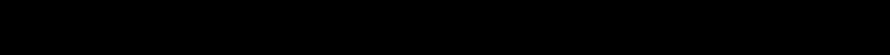
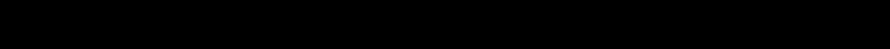
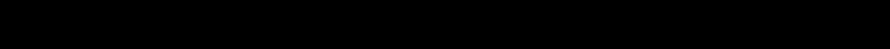

In [ ]:


TARGET_BOOK = 'Book2'
OUT_SHEET   = 'average_time_stable'  # 结果写到这个表（修正拼写）
MIN_WINDOW_LEN_SEC = 1               # 过滤过短片段（单位：秒）
IGNORE_FIRST_SEG = True              # 是否忽略首段

def estimate_step_seconds(t_arr: np.ndarray) -> int:
    """估计时间步长（多数情况下为 1 秒）。"""
    if t_arr.size < 2:
        return 1
    diffs = np.diff(t_arr)
    pos = diffs[diffs > 0]
    if pos.size == 0:
        return 1
    # 众数
    mode_val = int(pd.Series(pos).mode().iat[0])
    return max(1, mode_val)

def calculate(df: pd.DataFrame) -> tuple[float, int, int, int]:
    """
    计算平均/最大/最小“无建链稳定时长”（秒）以及片段数。
    片段定义：pending_edges==0 的极大连续区间（按 time 序列的值连续性，不按行数）。
    """
    # 预处理：只取需要的两列，转数值、去空、按 time 排序
    s = df[['time', 'merged_pending_edges']].copy()
    s['time'] = pd.to_numeric(s['time'], errors='coerce')
    s['pending_edges'] = pd.to_numeric(s['merged_pending_edges'], errors='coerce').fillna(0)
    s = s.dropna(subset=['time'])
    if s.empty:
        return 0.0, 0, 0, 0

    s['time'] = s['time'].astype(int)
    s = s.sort_values('time')
    t_arr = s['time'].to_numpy()
    e_arr = s['pending_edges'].astype(int).to_numpy()

    step = estimate_step_seconds(t_arr)

    # 遍历，抽取 pending_edges==0 的极大连续段（按 time 连续性）
    segments: list[tuple[int, int]] = []
    in_zero = (e_arr[0] == 0)
    seg_start = t_arr[0] if in_zero else None
    last_t = t_arr[0]

    for t, e in zip(t_arr[1:], e_arr[1:]):
        # 只要状态没变，就继续；状态变化时收段/开段
        if e == 0 and not in_zero:
            # False -> True：开始新段
            in_zero = True
            seg_start = t
        elif e != 0 and in_zero:
            # True -> False：收尾一段
            in_zero = False
            seg_end = last_t
            segments.append((seg_start, seg_end))
            seg_start = None
        last_t = t

    # 末尾收尾
    if in_zero and seg_start is not None:
        segments.append((seg_start, last_t))

    # 可选：忽略首段
    if IGNORE_FIRST_SEG and len(segments) >= 1:
        segments = segments[1:]

    if not segments:
        return 0.0, 0, 0, 0

    # 计算各段长度（秒）
    lengths = [max(0, (end - start) + step) for (start, end) in segments]
    # 过滤过短片段
    lengths = [L for L in lengths if L >= MIN_WINDOW_LEN_SEC]

    if not lengths:
        return 0.0, 0, 0, 0

    K = len(lengths)
    avg_len = sum(lengths) / K
    max_len = max(lengths)
    min_len = min(lengths)
    return float(avg_len), int(max_len), int(min_len), int(K)

# ============ 主流程 ============
bk = op.find_book('w', TARGET_BOOK)
if bk is None:
    raise RuntimeError(f"找不到工作簿 '{TARGET_BOOK}'")

results = []

for wks in bk:
    nm = wks.name
    if not nm.startswith('pending_edges_'):
        continue

    # 读取（Long Name 为表头）
    df = wks.to_df(head='L')
    if not {'time','merged_pending_edges'}.issubset(df.columns):
        print(f"跳过（缺列）: [{TARGET_BOOK}] {nm}")
        continue

    if df.empty:
        print(f"跳过（空表）: [{TARGET_BOOK}] {nm}")
        continue

    avg_len, max_len, min_len, seg_cnt = calculate(df)

    results.append({
        'book': TARGET_BOOK,
        'sheet': nm,
        'NSLTD': avg_len,
        'max_stable_time_sec': max_len,
        'min_stable_time_sec': min_len,
        'segments': seg_cnt,
    })

# 汇总并写回 Origin
if results:
    df_sum = pd.DataFrame(results)

    # 从 sheet 名里提取 ttb 数字用于排序（可选）
    def _pick_ttb(s):
        try:
            return int(''.join(ch for ch in s if ch.isdigit()))
        except Exception:
            return None

    df_sum['ttb'] = df_sum['sheet'].map(_pick_ttb)
    df_sum = df_sum.sort_values(['book','ttb'], na_position='last')

    cols = ['ttb', 'NSLTD', 'max_stable_time_sec',
            'min_stable_time_sec', 'segments']

    print("\n=== SUMMARY (Average Zero-Stable Length, seconds) ===")
    print(df_sum[cols].to_string(index=False))

    ws = write2origin.ensure_sheet(TARGET_BOOK, OUT_SHEET,
                                   clear_existing=True, activate=True)
    ws.from_df(df_sum[cols])

    print(f"写入完成 -> [{TARGET_BOOK}] {OUT_SHEET}")
else:
    print("没有匹配到 pending_edges_* 的工作表。")


###  平均无建链时间占比
No-Setup Link Time Ratio（NSLTR):平均无建链时间占比

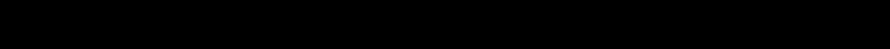

In [ ]:
# 不考虑缺口：仅按观测到的连续行里 pending_edges==0 计算窗口
# 仅遍历 Book1

import draw.pymatlab2.origin_function.write2origin as write2origin

MIN_WINDOW_LEN = 1    # 连续0窗口的最小长度（行数/秒数）
results = []


TARGET_BOOK = 'Book2'      # 只在 Book1 里统计
OUT_SHEET = 'zero_stable time and Proportion'   # 去掉尾部空格，避免重名问题

bk = op.find_book('w', TARGET_BOOK)
if bk is None:
    raise RuntimeError(f"未找到工作簿 '{TARGET_BOOK}'，请确认数据就在此书中。")

for wks in bk:
    nm = wks.name
    if not nm.startswith('pending_edges_ttb'):
        continue

    # ===== 读取（Long Name 作为表头）=====
    df = wks.to_df(head='L')
    if not {'time','merged_pending_edges'}.issubset(df.columns):
        print(f"跳过（缺列）: [Book1] {nm}")
        continue

    # ===== 规范化 =====
    df = df[['time','merged_pending_edges']].copy()
    df['time'] = pd.to_numeric(df['time'], errors='coerce')
    df['pending_edges'] = pd.to_numeric(df['merged_pending_edges'], errors='coerce')
    df = df.dropna(subset=['time']).copy()
    df['time'] = df['time'].astype(int)
    df = df.sort_values('time')

    if df.empty:
        print(f"跳过（空表）: [Book1] {nm}")
        continue

    # ===== 未建链占比：edge==0 计为“未建链”；NaN 按 0 处理；不考虑缺口 =====
    observed_seconds = int(len(df))                             # 分母：观测到的总时长（行数）
    no_link_seconds  = int(df['pending_edges'].fillna(0).eq(0).sum())  # 分子：edge==0 的时长
    no_link_ratio    = (no_link_seconds / observed_seconds) if observed_seconds > 0 else 0.0
    no_link_ratio_pct = round(no_link_ratio * 100.0, 4)

    print(f"[Book1] {nm} | no-link={no_link_seconds}s / {observed_seconds}s = {no_link_ratio_pct:.2f}%")

    results.append({
        'book': 'Book1',
        'sheet': nm,
        'time_min': int(df['time'].min()),
        'time_max': int(df['time'].max()),
        'observed_seconds': observed_seconds,
        'no_link_seconds': no_link_seconds,
        'no_link_ratio': round(no_link_ratio, 6),
        'NSLTR': no_link_ratio_pct,
    })

# ===== 汇总并写回 Origin(写到 Book1 -> "stable time and Proportion") =====
if results:
    df_sum = pd.DataFrame(results)

    # 从 sheet 名里提取 ttb 数字用于排序（可选）
    def _pick_ttb(s):
        try:
            return int(''.join(ch for ch in s if ch.isdigit()))
        except Exception:
            return None
    df_sum['ttb'] = df_sum['sheet'].map(_pick_ttb)
    df_sum = df_sum.sort_values(['book','ttb'], na_position='last')

    cols = ['ttb', 'NSLTR', 'no_link_seconds', 'observed_seconds']

    print("\n=== SUMMARY (No-Link Ratio) ===")
    print(df_sum[cols].to_string(index=False))

    ws = write2origin.ensure_sheet(TARGET_BOOK,  OUT_SHEET,
                                   clear_existing=True, activate=True)
    ws.from_df(df_sum[cols])

    print("写入完成 -> [Book1] stable time and Proportion")
else:
    print("没有匹配到 pending_edges_* 的工作表。")


### 平均建链条数




**meth1:总条数，目前不采用了**

In [ ]:


TARGET_BOOK = 'Book1'
OUT_SHEET   = 'avg_switches'   # 结果写到这个表

bk = op.find_book('w', TARGET_BOOK)
if bk is None:
    raise RuntimeError(f"找不到工作簿 '{TARGET_BOOK}'")

results = []

for wks in bk:
    nm = wks.name
    if not nm.startswith('pending_edges_'):
        continue

    # ===== 读取（Long Name 为表头）=====
    df = wks.to_df(head='L')
    if not {'time','pending_edges'}.issubset(df.columns):
        print(f"跳过（缺列）: [{TARGET_BOOK}] {nm}")
        continue

    # ===== 规范化 =====
    df = df[['time','pending_edges']].copy()
    df['time'] = pd.to_numeric(df['time'], errors='coerce')
    df['pending_edges'] = pd.to_numeric(df['pending_edges'], errors='coerce')
    df = df.dropna(subset=['time']).copy()
    df['time'] = df['time'].astype(int)
    df = df.sort_values('time')

    if df.empty:
        print(f"跳过（空表）: [{TARGET_BOOK}] {nm}")
        continue

    # ===== 平均切换条数（每秒平均）=====
    observed_seconds = int(len(df))                        # T
    pe = df['pending_edges'].fillna(0)                     # L_i（NaN 记为 0）
    sum_link = float(pe.sum())                             # Σ L_i
    avg_link = sum_link / observed_seconds if observed_seconds > 0 else 0.0  # ΣL_i / T

    # 参考指标（可选）
    max_link = int(pe.max()) if len(pe) else 0
    med_link = float(pe.median()) if len(pe) else 0.0

    print(f"[{TARGET_BOOK}] {nm} | avg_link={avg_link:.6f}  "
          f"(sum={sum_link:.0f}, T={observed_seconds}, max={max_link}, median={med_link:.2f})")

    results.append({
        'book': TARGET_BOOK,
        'sheet': nm,
        'time_min': int(df['time'].min()),
        'time_max': int(df['time'].max()),
        'observed_seconds': observed_seconds,   # T
        'sum_link': round(sum_link, 4),         # Σ L_i
        'avg_link': round(avg_link, 6),         # 平均切换条数（每秒）
        'max_link': max_link,
        'median_link': round(med_link, 4),
    })

# ===== 汇总并写回 Origin =====
if results:
    df_sum = pd.DataFrame(results)

    # 从 sheet 名里提取 ttb 数字用于排序（可选）
    def _pick_ttb(s):
        try:
            return int(''.join(ch for ch in s if ch.isdigit()))
        except Exception:
            return None
    df_sum['ttb'] = df_sum['sheet'].map(_pick_ttb)
    df_sum = df_sum.sort_values(['book','ttb'], na_position='last')

    cols = ['ttb', 'avg_link', 'sum_link', 'observed_seconds', 'max_link', 'median_link']

    print("\n=== SUMMARY (Average Switch Count) ===")
    print(df_sum[cols].to_string(index=False))

    ws = write2origin.ensure_sheet(TARGET_BOOK, OUT_SHEET, clear_existing=True, activate=True)
    ws.from_df(df_sum[cols])

    print(f"写入完成 -> [{TARGET_BOOK}] {OUT_SHEET}")
else:
    print("没有匹配到 pending_edges_* 的工作表。")

mthod2：分析p1 和p2 的

这里的算法，指的是关于处理p1 p2 pending edge的对比

In [ ]:
# 该代码是不用的
TARGET_BOOK = 'Book2'
OUT_SHEET   = 'avg_switches_P1'   # 结果写到这个表
import  re
bk = op.find_book('w', TARGET_BOOK)
if bk is None:
    raise RuntimeError(f"找不到工作簿 '{TARGET_BOOK}'")

results = []

for wks in bk:
    nm = wks.name
    if not nm.startswith('p1_pending_edges_'):
        continue

    # ===== 读取（Long Name 为表头）=====
    df = wks.to_df(head='L')
    if not {'time','pending_edges'}.issubset(df.columns):
        print(f"跳过（缺列）: [{TARGET_BOOK}] {nm}")
        continue

    # ===== 规范化 =====
    df = df[['time','pending_edges']].copy()
    df['time'] = pd.to_numeric(df['time'], errors='coerce')
    df['pending_edges'] = pd.to_numeric(df['pending_edges'], errors='coerce')
    df = df.dropna(subset=['time']).copy()
    df['time'] = df['time'].astype(int)
    df = df.sort_values('time')

    if df.empty:
        print(f"跳过（空表）: [{TARGET_BOOK}] {nm}")
        continue

    # ===== 平均切换条数（每秒平均）=====
    observed_seconds = int(len(df))                        # T
    pe = df['pending_edges'].fillna(0)                     # L_i（NaN 记为 0）
    sum_link = float(pe.sum())                             # Σ L_i
    avg_link = sum_link / observed_seconds if observed_seconds > 0 else 0.0  # ΣL_i / T

    # 参考指标（可选）


    print(f"[{TARGET_BOOK}] {nm} | avg_link={avg_link:.6f}  "
          f"(sum={sum_link:.0f}, T={observed_seconds}  )")

    results.append({
        'book': TARGET_BOOK,
        'sheet': nm,
        'time_min': int(df['time'].min()),
        'time_max': int(df['time'].max()),
        'observed_seconds': observed_seconds,   # T
        'sum_link': round(sum_link, 4),         # Σ L_i
        'avg_link': round(avg_link, 6),         # 平均切换条数（每秒）

    })

# ===== 汇总并写回 Origin =====
if results:
    df_sum = pd.DataFrame(results)

    # 从 sheet 名里提取 ttb 数字用于排序（可选）
    def _pick_ttb(s: str):
        m = re.search(r'(?<=ttb)\s*(\d+)\s*$', s)  # 优先匹配 "...ttbXX" 末尾
        if m:
            return int(m.group(1))
        m2 = re.search(r'(\d+)\s*$', s)            # 兜底：取末尾数字
        return int(m2.group(1)) if m2 else None



    df_sum['ttb'] = df_sum['sheet'].map(_pick_ttb)
    df_sum = df_sum.sort_values(['book','ttb'], na_position='last')

    cols = ['ttb', 'avg_link', 'sum_link', 'observed_seconds',  ]

    print("\n=== SUMMARY (Average Switch Count) ===")
    print(df_sum[cols].to_string(index=False))

    ws = write2origin.ensure_sheet(TARGET_BOOK, OUT_SHEET, clear_existing=True, activate=True)
    ws.from_df(df_sum[cols])

    print(f"写入完成 -> [{TARGET_BOOK}] {OUT_SHEET}")
else:
    print("没有匹配到 pending_edges_* 的工作表。")

这个就是描述p1 和p2的一个数据

也就是Average Number of Setup Links(ANSL)



In [ ]:
 # -*- coding: utf-8 -*-
 # 主要是用这段代码
import re
import pandas as pd
import originpro as op
from draw.pymatlab2.origin_function import write2origin

TARGET_BOOK = 'Book1'
OUT_SHEET   = 'avg_switches_P1_P2'   # 一张表里放 p1/p2 的平均值

def _pick_ttb(name: str):
    """从工作表名中抽取末尾的 ttb 数字：...ttb60 -> 60"""
    m = re.search(r'(?<=ttb)\s*(\d+)\s*$', name)
    if m:
        return int(m.group(1))
    m2 = re.search(r'(\d+)\s*$', name)  # 兜底
    return int(m2.group(1)) if m2 else None

def _avg_switches_from_df(df: pd.DataFrame) -> float:
    """计算每秒平均 pending_edges（ΣL_i / T）。"""
    s = df[['time', 'pending_edges']].copy()
    s['time'] = pd.to_numeric(s['time'], errors='coerce')
    s['pending_edges'] = pd.to_numeric(s['pending_edges'], errors='coerce')
    s = s.dropna(subset=['time'])
    if s.empty:
        return float('nan')
    s['time'] = s['time'].astype(int)
    s = s.sort_values('time')
    T = int(len(s))
    if T == 0:
        return float('nan')
    pe = s['pending_edges'].fillna(0)
    return float(pe.sum()) / T

def _collect_avg_by_prefix(bk, prefix: str) -> dict[int, float]:
    """遍历以 prefix 开头的工作表，返回 {ttb: avg}。"""
    out = {}
    for wks in bk:
        nm = wks.name
        if not nm.startswith(prefix):
            continue
        df = wks.to_df(head='L')
        if not {'time','pending_edges'}.issubset(df.columns):
            continue
        ttb = _pick_ttb(nm)
        if ttb is None:
            continue
        out[ttb] = _avg_switches_from_df(df)
    return out

# ===== 主流程 =====
bk = op.find_book('w', TARGET_BOOK)
if bk is None:
    raise RuntimeError(f"找不到工作簿 '{TARGET_BOOK}'")

p1_map = _collect_avg_by_prefix(bk, 'p1_pending_edges_')
p2_map = _collect_avg_by_prefix(bk, 'p2_pending_edges_')

# 合并到一张表（按 ttb 排序）
ttbs = sorted(set(p1_map) | set(p2_map))
rows = []
for t in ttbs:
    rows.append({
        'ttb': t,
        'avg_link_p1': float(p1_map.get(t, float('nan'))),
        'avg_link_p2': float(p2_map.get(t, float('nan'))),
    })
df_out = pd.DataFrame(rows).sort_values('ttb')

# 写回 Origin
ws = write2origin.ensure_sheet(TARGET_BOOK, OUT_SHEET, clear_existing=True, activate=True)
ws.from_df(df_out[['ttb', 'avg_link_p1', 'avg_link_p2']])

print(f"写入完成 -> [{TARGET_BOOK}] {OUT_SHEET}")
print(df_out.to_string(index=False))


## 稳定拓扑

下面介绍的是稳定拓扑，也就是实际上卫星网络工作时候的拓扑形状


In [ ]:
TTB_VALUES = [  10,20,30,40,50,60, 70, 80,90, 100, 110, 120,130,140]
BOOKname = "Book3"
for ttb in TTB_VALUES:
    DEFAULT_VERSION = f"{SIMULATION_EDITION}/topology_{ttb}"
    VERSION = os.getenv("TOPOLOGY_VERSION", DEFAULT_VERSION)
    # VERSION = os.getenv("TOPOLOGY_VERSION", f"topology_{ttb}")
    FIGURE_DIR    = Path(INPUT_DIR) / VERSION / "figure"

    filename = f"topology_snapshot_ttb{ttb}"


    csv1_path = FIGURE_DIR / f"{filename}.csv"

    csv2origin.csv_to_origin(csv1_path, book=BOOKname, sheet=filename, clear=True)
    #下面是补全，目前的pending edge一般是要补全的




下面都是一些测试

In [ ]:
# 不考虑缺口：仅按观测到的连续行里 pending_edges==0 计算窗口
# 仅遍历 Book1

import draw.pymatlab2.origin_function.write2origin as write2origin

MIN_WINDOW_LEN = 1    # 连续0窗口的最小长度（行数/秒数）
results = []


TARGET_BOOK = 'Book2'      # 只在 Book1 里统计
OUT_SHEET = 'topology_change_summary2'   # 去掉尾部空格，避免重名问题

bk = op.find_book('w', TARGET_BOOK)
if bk is None:
    raise RuntimeError(f"未找到工作簿 '{TARGET_BOOK}'，请确认数据就在此书中。")

sheetname  = "topology_change_summary"
wks = op.find_sheet('w', '[TARGET_BOOK]sheetname')


In [ ]:
 #测试
TARGET_BOOK = 'Book3'
SRC_SHEET   = 'topology_snapshot_ttb60'    # 源表：含 t / link_count / changed


# ===== 1) 用你要求的方式找到源表 =====
wks = op.find_sheet('w', f'[{TARGET_BOOK}]{SRC_SHEET}')
if wks is None:
    raise RuntimeError(f"在工作簿 '{TARGET_BOOK}' 中未找到工作表 '{SRC_SHEET}'")

# ===== 2) 读取数据（用 Long Name 作列名）=====
df = wks.to_df(head='L')
need = {'t','link_count','changed'}
if not need.issubset(df.columns):
    raise RuntimeError(f"源表缺列，需包含 {need}，实际为：{set(df.columns)}")

# 规范化
df['t']          = pd.to_numeric(df['t'], errors='coerce')
df['link_count'] = pd.to_numeric(df['link_count'], errors='coerce')
df['changed']    = pd.to_numeric(df['changed'], errors='coerce').fillna(0).astype(int)
df = df.dropna(subset=['t','link_count']).sort_values('t').reset_index(drop=True)

# ===== 3) 计算三列：stable_line / change_line / change_mark =====


# 基础性函数
这里主要介绍了一些基础函数的使用案例，基本上都有，直接抄着看就行

In [ ]:
# find the target sheet and read
TARGET_BOOK = "Book1"
sheetname   = "MergeData"

wks = op.find_sheet('w', f'[{TARGET_BOOK}]{sheetname}')



In [ ]:
# write the arrary to the book sheet
# attention ,the function
# to_origin
import pandas as pd
import numpy as np

# 1. 构造包含 X轴(k) 和 Y轴(score) 的字典，并转为 DataFrame
# 假设 score_array 已经由上一步的 find_optimal_shift 计算得出

N = len(score_array)
df_to_export = pd.DataFrame({
    "Shift_k": np.arange(N),       # 第一列：偏移量 k (0 到 N-1)
    "Avg_Score": score_array       # 第二列：对应的平均跳数 h_k[n]
})

# 2. 调用你自定义的写入函数
# 你可以自定义 book 和 sheet 的名字，比如存到 "Optimization" 工作簿的 "ScoreData" 表中
try:
    csv2origin.to_origin(df_to_export, book="Optimization", sheet="ScoreData", clear=True)
    print("数据已成功写入 Origin！工作簿: Optimization, 工作表: ScoreData")
except Exception as e:
    print(f"写入 Origin 时发生错误: {e}")



In [ ]:
#测试
import  draw.pymatlab2.origin_function.get_qujian as get_qujian




# df 为包含 t / link_count / changed 的 DataFrame
qujian = get_qujian.extract_stable_intervals(df, rep_stat="mean")

# print(f"共找到 {len(qujian)} 个稳定区间")
# for i, q in enumerate(qujian, 1):
#     print(f"区间{i}: t∈{q.interval}, 平均边数={q.edges:.1f}, 时长={q.length:.1f}")

# 求平均稳定时长
avg_len = np.mean([q.length for q in qujian])
print(f"平均稳定拓扑时长: {avg_len:.2f}")



In [ ]:
 #测试

TARGET_BOOK = 'Book3'
SRC_SHEET   = 'topology_snapshot_ttb10'    # 源表：含 t / link_count / changed


# ===== 1) 用你要求的方式找到源表 =====
wks = op.find_sheet('w', f'[{TARGET_BOOK}]{SRC_SHEET}')
if wks is None:
    raise RuntimeError(f"在工作簿 '{TARGET_BOOK}' 中未找到工作表 '{SRC_SHEET}'")

# ===== 2) 读取数据（用 Long Name 作列名）=====
df = wks.to_df(head='L')
need = {'t','link_count','changed'}
if not need.issubset(df.columns):
    raise RuntimeError(f"源表缺列，需包含 {need}，实际为：{set(df.columns)}")

# 规范化
df['t']          = pd.to_numeric(df['t'], errors='coerce')
df['link_count'] = pd.to_numeric(df['link_count'], errors='coerce')
df['changed']    = pd.to_numeric(df['changed'], errors='coerce').fillna(0).astype(int)
df = df.dropna(subset=['t','link_count']).sort_values('t').reset_index(drop=True)

# ===== 3) 计算三列：stable_line / change_line / change_mark =====

# df 为包含 t / link_count / changed 的 DataFrame
qujian = get_qujian.extract_stable_intervals(df, rep_stat="mean")


for i in range(len(qujian)-1 ):
    if qujian[i].edges ==qujian[i+1].edges :
        print(i)


print(f"共找到 {len(qujian)} 个稳定区间")

for i, q in enumerate(qujian, 1):
    print(f"区间{i}: t∈{q.interval}, 平均边数={q.edges:.1f}, 时长={q.length:.1f}")

# 求平均稳定时长
# avg_len = np.mean([q.length for q in qujian])
# print(f"平均稳定拓扑时长: {avg_len:.2f}")



In [ ]:
# 该代码是不用的
import  draw.pymatlab2.origin_function.get_qujian as get_qujian

TARGET_BOOK = 'Book3'
OUT_SHEET   = 'avg_topology'   # 结果写到这个表
import  re
bk = op.find_book('w', TARGET_BOOK)
if bk is None:
    raise RuntimeError(f"找不到工作簿 '{TARGET_BOOK}'")

results = []

for wks in bk:
    nm = wks.name
    if not nm.startswith('topology_snapshot_ttb'):
        continue

    # ===== 读取（Long Name 为表头）=====
    df = wks.to_df(head='L')
    if not {'t','link_count','changed'}.issubset(df.columns):
        print(f"跳过（缺列）: [{TARGET_BOOK}] {nm}")
        continue

    # ===== 规范化 =====
    df = df[['t','link_count','changed']].copy()

    df['t'] = pd.to_numeric(df['t'], errors='coerce')
    df['link_count'] = pd.to_numeric(df['link_count'], errors='coerce')
    df['changed'] = pd.to_numeric(df['changed'], errors='coerce')

    df = df.dropna(subset=['t']).copy()
    df['t'] = df['t'].astype(int)
    df = df.sort_values('t')

    if df.empty:
        print(f"跳过（空表）: [{TARGET_BOOK}] {nm}")
        continue

    # ===== 平均切换条数（每秒平均）=====
    qujian = get_qujian.extract_stable_intervals(df, rep_stat="mean")

    avg_time_len = np.mean([q.length for q in qujian])
    avg_edges = np.mean([q.edges for q in qujian])
    # observed_seconds = int(len(df))                        # T
    # pe = df['pending_edges'].fillna(0)                     # L_i（NaN 记为 0）
    # sum_link = float(pe.sum())                             # Σ L_i
    # avg_link = sum_link / observed_seconds if observed_seconds > 0 else 0.0  # ΣL_i / T

    # 参考指标（可选）


    # print(f"[{TARGET_BOOK}] {nm} | avg_link={avg_link:.6f}  "
    #       f"(sum={sum_link:.0f}, T={observed_seconds}, max={max_link}, median={med_link:.2f})")

    results.append({
        'book': TARGET_BOOK,
        'sheet': nm,
        'interval_number': len(qujian),
        'MSTD': avg_time_len,   # T
        'MSTE': avg_edges,   # T


    })

# ===== 汇总并写回 Origin =====
if results:
    df_sum = pd.DataFrame(results)

    # 从 sheet 名里提取 ttb 数字用于排序（可选）
    def _pick_ttb(s: str):
        m = re.search(r'(?<=ttb)\s*(\d+)\s*$', s)  # 优先匹配 "...ttbXX" 末尾
        if m:
            return int(m.group(1))
        m2 = re.search(r'(\d+)\s*$', s)            # 兜底：取末尾数字
        return int(m2.group(1)) if m2 else None



    df_sum['ttb'] = df_sum['sheet'].map(_pick_ttb)
    df_sum = df_sum.sort_values(['book','ttb'], na_position='last')

    cols = ['ttb', 'interval_number','MSTD',   'MSTE'  ]

    print("\n=== SUMMARY (Average Switch Count) ===")
    print(df_sum[cols].to_string(index=False))

    ws = write2origin.ensure_sheet(TARGET_BOOK, OUT_SHEET, clear_existing=True, activate=True)
    ws.from_df(df_sum[cols])

    print(f"写入完成 -> [{TARGET_BOOK}] {OUT_SHEET}")
else:
    print("没有匹配到 pending_edges_* 的工作表。")

## 最短路径的输入

最短路径是不需要进行后期处理的，导入即可

In [ ]:



BOOKname = "Book4"


TTB_VALUES = [  10,20,30,40,50,60, 70, 80,90, 100, 110, 120,130,140]
# TTB_VALUES = [  60, 70, 80,90, 100, 110, 120,130,140]

for ttb in TTB_VALUES:
    DEFAULT_VERSION = f"{SIMULATION_EDITION}/topology_{ttb}"
    VERSION = os.getenv("TOPOLOGY_VERSION", DEFAULT_VERSION)
    # VERSION = os.getenv("TOPOLOGY_VERSION", f"topology_{ttb}")
    FIGURE_DIR    = Path(INPUT_DIR) / VERSION / "figure"

    filename = f"avgspath_{ttb}"


    csv1_path = FIGURE_DIR / f"{filename}.csv"

    csv2origin.csv_to_origin(csv1_path, book=BOOKname, sheet=filename, clear=True)



RAW_VERSION = f"{SIMULATION_EDITION}/raw"
FIGURE_DIR    = Path(INPUT_DIR) / RAW_VERSION / "figure"
filename = f"avgspath_0"
csv1_path = FIGURE_DIR / f"{filename}.csv"

csv2origin.csv_to_origin(csv1_path, book=BOOKname, sheet=filename, clear=True)


In [ ]:
BOOKname = "Book4"
FIGURE_DIR    = Path(INPUT_DIR) / "grid+" / "figure"
filename = f"avgspath_g0_4_baseline"
csv1_path = FIGURE_DIR / f"{filename}.csv"

csv2origin.csv_to_origin(csv1_path, book=BOOKname, sheet=filename, clear=True)


首先探寻lst对平均最短路径的影响

In [ ]:
import draw.pymatlab2.origin_function.write2origin as write2origin
import  draw.pymatlab2.basic.get_mean_var as get_mean_var
import re
TARGET_BOOK = 'Book4'
OUT_SHEET   = 'avgspath_all '   # 结果写到这个表

bk = op.find_book('w', TARGET_BOOK)
if bk is None:
    raise RuntimeError(f"找不到工作簿 '{TARGET_BOOK}'")

results = []


for wks in bk:
    nm = wks.name
    if not nm.startswith('avgspath_'):
        continue

    # ===== 读取（Long Name 为表头）=====
    df = wks.to_df(head='L')
    if not {'time','avg_shortest_path'}.issubset(df.columns):
        print(f"跳过（缺列）: [{TARGET_BOOK}] {nm}")
        continue

    # ===== 规范化 =====
    df = df[['time','avg_shortest_path']].copy()
    # df['time'] = pd.to_numeric(df['time'], errors='coerce')
    # df['avg_shortest_path'] = pd.to_numeric(df['avg_shortest_path'], errors='coerce')
    # df = df.dropna(subset=['time']).copy()
    # df['time'] = df['time'].astype(int)
    # df = df.sort_values('time')

    if df.empty:
        print(f"跳过（空表）: [{TARGET_BOOK}] {nm}")
        continue
# 3. 调用

    df_tv = df[['time', 'avg_shortest_path']].copy()

    mean_hops, std_hops = get_mean_var.calc_mean_std(df_tv)


    results.append({
        'book': TARGET_BOOK,
        'sheet': nm,
        'avg_hops': mean_hops,
            'std_val': std_hops,                     # ← 新增


    })

# ===== 汇总并写回 Origin =====
if results:
    df_sum = pd.DataFrame(results)

    # 从 sheet 名里提取 ttb 数字用于排序（可选）
    # def _pick_ttb(s):
    #     try:
    #         return int(''.join(ch for ch in s if ch.isdigit()))
    #     except Exception:
    #         return None
    def _pick_ttb(s: str):
    # 只取 ttb 后面连续的数字，忽略前面的 g0_4 等
        m = re.search(r'avgspath_[_\s-]*?(\d+)\b', s, flags=re.IGNORECASE)
        return int(m.group(1)) if m else None

    df_sum['ttb'] = df_sum['sheet'].map(_pick_ttb)
    df_sum = df_sum.sort_values(['book','ttb'], na_position='last')

    # cols = ['ttb', 'avg_hops',  ]
    cols = ['ttb', 'avg_hops', 'std_val']


    print("\n=== SUMMARY (Average Switch Count) ===")
    print(df_sum[cols].to_string(index=False))

    ws = write2origin.ensure_sheet(TARGET_BOOK, OUT_SHEET, clear_existing=True, activate=True)
    ws.from_df(df_sum[cols])

    print(f"写入完成 -> [{TARGET_BOOK}] {OUT_SHEET}")
else:
    print("没有匹配到 pending_edges_* 的工作表。")

然后，我们求解，不同lst下，这个lst带来的影响

In [ ]:
import draw.pymatlab2.origin_function.write2origin as write2origin
import  draw.pymatlab2.basic.get_mean_var as get_mean_var
import re
TARGET_BOOK = 'Book4'
# 找到 [Book5]test 这个工作表

wks = op.find_sheet('w', '[Book4]avgspath_0')
if wks is None:
    raise RuntimeError("找不到工作表 [Book5]test")

# 读成 DataFrame，首行作为列名
base = wks.to_df(head='L')
# print(df.head())
base_tv = base[['time', 'avg_shortest_path']].copy()

OUT_SHEET   = 'avgspath_vs_lst '   # 结果写到这个表

bk = op.find_book('w', TARGET_BOOK)
if bk is None:
    raise RuntimeError(f"找不到工作簿 '{TARGET_BOOK}'")

results = []


for wks in bk:
    nm = wks.name
    if not nm.startswith('avgspath_'):
        continue
    if nm.startswith('avgspath_0'):
        continue
    if nm.startswith('avgspath_all'):
        continue

    # ===== 读取（Long Name 为表头）=====
    df = wks.to_df(head='L')
    if not {'time','avg_shortest_path'}.issubset(df.columns):
        print(f"跳过（缺列）: [{TARGET_BOOK}] {nm}")
        continue

    # ===== 规范化 =====
    df = df[['time','avg_shortest_path']].copy()
    # df['time'] = pd.to_numeric(df['time'], errors='coerce')
    # df['avg_shortest_path'] = pd.to_numeric(df['avg_shortest_path'], errors='coerce')
    # df = df.dropna(subset=['time']).copy()
    # df['time'] = df['time'].astype(int)
    # df = df.sort_values('time')

    if df.empty:
        print(f"跳过（空表）: [{TARGET_BOOK}] {nm}")
        continue
# 3. 调用

    df_tv = df[['time', 'avg_shortest_path']].copy()

    # 假设 base_tv 也是一个 DataFrame/Series，index 对齐
    diff = df_tv['avg_shortest_path'] - base_tv['avg_shortest_path']

    df_tv_all = pd.DataFrame({
        'time': df_tv['time'],
        'avg_shortest_path_diff': diff,
    })

    mean_hops, std_hops = get_mean_var.calc_mean_std(df_tv_all)


    results.append({
        'book': TARGET_BOOK,
        'sheet': nm,
        'avg_hops': mean_hops,
            'std_val': std_hops,                     # ← 新增


    })

# ===== 汇总并写回 Origin =====
if results:
    df_sum = pd.DataFrame(results)

    # 从 sheet 名里提取 ttb 数字用于排序（可选）
    # def _pick_ttb(s):
    #     try:
    #         return int(''.join(ch for ch in s if ch.isdigit()))
    #     except Exception:
    #         return None
    def _pick_ttb(s: str):
    # 只取 ttb 后面连续的数字，忽略前面的 g0_4 等
        m = re.search(r'avgspath_[_\s-]*?(\d+)\b', s, flags=re.IGNORECASE)
        return int(m.group(1)) if m else None

    df_sum['ttb'] = df_sum['sheet'].map(_pick_ttb)
    df_sum = df_sum.sort_values(['book','ttb'], na_position='last')

    # cols = ['ttb', 'avg_hops',  ]
    cols = ['ttb', 'avg_hops', 'std_val']


    print("\n=== SUMMARY (Average Switch Count) ===")
    print(df_sum[cols].to_string(index=False))

    ws = write2origin.ensure_sheet(TARGET_BOOK, OUT_SHEET, clear_existing=True, activate=True)
    ws.from_df(df_sum[cols])

    print(f"写入完成 -> [{TARGET_BOOK}] {OUT_SHEET}")
else:
    print("没有匹配到 pending_edges_* 的工作表。")

In [ ]:
# 找到 [Book5]test 这个工作表

wks = op.find_sheet('w', '[Book8]minhops_huasha_wulumuqi_grid')
if wks is None:
    raise RuntimeError("找不到工作表 [Book5]test")

# 读成 DataFrame，首行作为列名
df = wks.to_df(head='L')
print(df.head())

df_tv = df[['time', 'min_shortest_path']].copy()

mean_hops, std_hops = get_mean_var.calc_mean_std(df_tv)
print("平均值 =", mean_hops)
print("标准差 =", std_hops)


感兴趣卫星对的导入

In [ ]:
# 找到 [Book5]test 这个工作表

wks = op.find_sheet('w', '[Book4]minhops_boling_beijin_ttb60')
if wks is None:
    raise RuntimeError("找不到工作表 [Book5]test")

# 读成 DataFrame，首行作为列名
df = wks.to_df(head='L')
print(df.head())

In [ ]:
# 3. 调用
import  draw.pymatlab2.basic.get_mean_var as get_mean_var
df_tv = df[['time', 'min_shortest_path']].copy()

mean_hops, std_hops = get_mean_var.calc_mean_std(df_tv)
print("平均值 =", mean_hops)
print("标准差 =", std_hops)

BOOK5

城市对数据导如

In [ ]:


BOOKname = "Book5"


TTB_VALUES = [  10,20,30,40,50,60, 70, 80,90, 100, 110, 120,130,140]

for ttb in TTB_VALUES:
    #VERSION = os.getenv("TOPOLOGY_VERSION", f"topology_{ttb}")
    DEFAULT_VERSION = f"{SIMULATION_EDITION}/topology_{ttb}"
    VERSION = os.getenv("TOPOLOGY_VERSION", DEFAULT_VERSION)

    FIGURE_DIR    = Path(INPUT_DIR) / VERSION / "figure"

    filename = f"minhops_boling_beijin_ttb{ttb}"


    csv1_path = FIGURE_DIR / f"{filename}.csv"

    csv2origin.csv_to_origin(csv1_path, book=BOOKname, sheet=filename, clear=True)


RAW_VERSION = f"{SIMULATION_EDITION}/raw"
FIGURE_DIR    = Path(INPUT_DIR) / RAW_VERSION / "figure"
filename = f"minhops_boling_beijin_ttb0"
csv1_path = FIGURE_DIR / f"{filename}.csv"


csv2origin.csv_to_origin(csv1_path, book=BOOKname, sheet=filename, clear=True)

In [ ]:
import  draw.pymatlab2.basic.get_mean_var as get_mean_var

接下来就是求解均指和方差

In [ ]:
# 3. 调用
import  draw.pymatlab2.basic.get_mean_var as get_mean_var
df_tv = df[['time', 'min_shortest_path']].copy()

mean_hops, std_hops = get_mean_var.calc_mean_std(df_tv)
print("平均值 =", mean_hops)
print("标准差 =", std_hops)

In [ ]:
import draw.pymatlab2.origin_function.write2origin as write2origin
import re
TARGET_BOOK = 'Book5'
OUT_SHEET   = 'boling_beijin '   # 结果写到这个表

bk = op.find_book('w', TARGET_BOOK)
if bk is None:
    raise RuntimeError(f"找不到工作簿 '{TARGET_BOOK}'")

results = []


for wks in bk:
    nm = wks.name
    if not nm.startswith('minhops_boling_beijin_ttb'):
        continue

    # ===== 读取（Long Name 为表头）=====
    df = wks.to_df(head='L')
    if not {'time','min_shortest_path'}.issubset(df.columns):
        print(f"跳过（缺列）: [{TARGET_BOOK}] {nm}")
        continue

    # ===== 规范化 =====
    df = df[['time','min_shortest_path']].copy()
    df['time'] = pd.to_numeric(df['time'], errors='coerce')
    df['min_shortest_path'] = pd.to_numeric(df['min_shortest_path'], errors='coerce')
    df = df.dropna(subset=['time']).copy()
    df['time'] = df['time'].astype(int)
    df = df.sort_values('time')

    if df.empty:
        print(f"跳过（空表）: [{TARGET_BOOK}] {nm}")
        continue
    df_tv = df[['time', 'min_shortest_path']].copy()
    mean_hops, std_hops = get_mean_var.calc_mean_std(df_tv)


    results.append({
        'book': TARGET_BOOK,
        'sheet': nm,
        'mean_hops': mean_hops,
            'std_hops': std_hops,                     # ← 新增


    })

# ===== 汇总并写回 Origin =====
if results:
    df_sum = pd.DataFrame(results)


    def _pick_ttb(s: str):
    # 只取 ttb 后面连续的数字，忽略前面的 g0_4 等
        m = re.search(r'ttb[_\s-]*?(\d+)\b', s, flags=re.IGNORECASE)
        return int(m.group(1)) if m else None
    df_sum['ttb'] = df_sum['sheet'].map(_pick_ttb)
    df_sum = df_sum.sort_values(['book','ttb'], na_position='last')

    # cols = ['ttb', 'avg_hops',  ]
    cols = ['ttb', 'mean_hops', 'std_hops']


    print("\n=== SUMMARY (Average Switch Count) ===")
    print(df_sum[cols].to_string(index=False))

    ws = write2origin.ensure_sheet(TARGET_BOOK, OUT_SHEET, clear_existing=True, activate=True)
    ws.from_df(df_sum[cols])

    print(f"写入完成 -> [{TARGET_BOOK}] {OUT_SHEET}")
else:
    print("没有匹配到 pending_edges_* 的工作表。")

In [ ]:


BOOKname = "Book6"


TTB_VALUES = [  10,20,30,40,50,60, 70, 80,90, 100, 110, 120,130,140]

for ttb in TTB_VALUES:
    #VERSION = os.getenv("TOPOLOGY_VERSION", f"topology_{ttb}")
    DEFAULT_VERSION = f"{SIMULATION_EDITION}/topology_{ttb}"
    VERSION = os.getenv("TOPOLOGY_VERSION", DEFAULT_VERSION)

    FIGURE_DIR    = Path(INPUT_DIR) / VERSION / "figure"

    filename = f"minhops_paris_chongqin_ttb{ttb}"


    csv1_path = FIGURE_DIR / f"{filename}.csv"

    csv2origin.csv_to_origin(csv1_path, book=BOOKname, sheet=filename, clear=True)


RAW_VERSION = f"{SIMULATION_EDITION}/raw"
FIGURE_DIR    = Path(INPUT_DIR) / RAW_VERSION / "figure"
filename = f"minhops_paris_chongqin_ttb0"
csv1_path = FIGURE_DIR / f"{filename}.csv"


csv2origin.csv_to_origin(csv1_path, book=BOOKname, sheet=filename, clear=True)

In [ ]:
import draw.pymatlab2.origin_function.write2origin as write2origin
import re
TARGET_BOOK = 'Book6'
OUT_SHEET   = 'paris_chongqin '   # 结果写到这个表

bk = op.find_book('w', TARGET_BOOK)
if bk is None:
    raise RuntimeError(f"找不到工作簿 '{TARGET_BOOK}'")

results = []


for wks in bk:
    nm = wks.name
    if not nm.startswith('minhops_paris_chongqin_ttb'):
        continue

    # ===== 读取（Long Name 为表头）=====
    df = wks.to_df(head='L')
    if not {'time','min_shortest_path'}.issubset(df.columns):
        print(f"跳过（缺列）: [{TARGET_BOOK}] {nm}")
        continue

    # ===== 规范化 =====
    df = df[['time','min_shortest_path']].copy()
    df['time'] = pd.to_numeric(df['time'], errors='coerce')
    df['min_shortest_path'] = pd.to_numeric(df['min_shortest_path'], errors='coerce')
    df = df.dropna(subset=['time']).copy()
    df['time'] = df['time'].astype(int)
    df = df.sort_values('time')

    if df.empty:
        print(f"跳过（空表）: [{TARGET_BOOK}] {nm}")
        continue
    df_tv = df[['time', 'min_shortest_path']].copy()
    mean_hops, std_hops = get_mean_var.calc_mean_std(df_tv)


    results.append({
        'book': TARGET_BOOK,
        'sheet': nm,
        'mean_hops': mean_hops,
            'std_hops': std_hops,                     # ← 新增


    })

# ===== 汇总并写回 Origin =====
if results:
    df_sum = pd.DataFrame(results)


    def _pick_ttb(s: str):
    # 只取 ttb 后面连续的数字，忽略前面的 g0_4 等
        m = re.search(r'ttb[_\s-]*?(\d+)\b', s, flags=re.IGNORECASE)
        return int(m.group(1)) if m else None
    df_sum['ttb'] = df_sum['sheet'].map(_pick_ttb)
    df_sum = df_sum.sort_values(['book','ttb'], na_position='last')

    # cols = ['ttb', 'avg_hops',  ]
    cols = ['ttb', 'mean_hops', 'std_hops']


    print("\n=== SUMMARY (Average Switch Count) ===")
    print(df_sum[cols].to_string(index=False))

    ws = write2origin.ensure_sheet(TARGET_BOOK, OUT_SHEET, clear_existing=True, activate=True)
    ws.from_df(df_sum[cols])

    print(f"写入完成 -> [{TARGET_BOOK}] {OUT_SHEET}")
else:
    print("没有匹配到 pending_edges_* 的工作表。")

In [ ]:


BOOKname = "Book7"


TTB_VALUES = [  10,20,30,40,50,60, 70, 80,90, 100, 110, 120,130,140]

for ttb in TTB_VALUES:
    #VERSION = os.getenv("TOPOLOGY_VERSION", f"topology_{ttb}")
    DEFAULT_VERSION = f"{SIMULATION_EDITION}/topology_{ttb}"
    VERSION = os.getenv("TOPOLOGY_VERSION", DEFAULT_VERSION)

    FIGURE_DIR    = Path(INPUT_DIR) / VERSION / "figure"

    filename = f"minhops_huasha_wulumuqi_ttb{ttb}"


    csv1_path = FIGURE_DIR / f"{filename}.csv"

    csv2origin.csv_to_origin(csv1_path, book=BOOKname, sheet=filename, clear=True)


RAW_VERSION = f"{SIMULATION_EDITION}/raw"
FIGURE_DIR    = Path(INPUT_DIR) / RAW_VERSION / "figure"
filename = f"minhops_huasha_wulumuqi_ttb0"
csv1_path = FIGURE_DIR / f"{filename}.csv"


csv2origin.csv_to_origin(csv1_path, book=BOOKname, sheet=filename, clear=True)

In [ ]:
import draw.pymatlab2.origin_function.write2origin as write2origin
import re
TARGET_BOOK = 'Book7'
OUT_SHEET   = 'huasha_wulumuqi '   # 结果写到这个表

bk = op.find_book('w', TARGET_BOOK)
if bk is None:
    raise RuntimeError(f"找不到工作簿 '{TARGET_BOOK}'")

results = []


for wks in bk:
    nm = wks.name
    if not nm.startswith('minhops_huasha_wulumuqi_ttb'):
        continue

    # ===== 读取（Long Name 为表头）=====
    df = wks.to_df(head='L')
    if not {'time','min_shortest_path'}.issubset(df.columns):
        print(f"跳过（缺列）: [{TARGET_BOOK}] {nm}")
        continue

    # ===== 规范化 =====
    df = df[['time','min_shortest_path']].copy()
    df['time'] = pd.to_numeric(df['time'], errors='coerce')
    df['min_shortest_path'] = pd.to_numeric(df['min_shortest_path'], errors='coerce')
    df = df.dropna(subset=['time']).copy()
    df['time'] = df['time'].astype(int)
    df = df.sort_values('time')

    if df.empty:
        print(f"跳过（空表）: [{TARGET_BOOK}] {nm}")
        continue
    df_tv = df[['time', 'min_shortest_path']].copy()
    mean_hops, std_hops = get_mean_var.calc_mean_std(df_tv)


    results.append({
        'book': TARGET_BOOK,
        'sheet': nm,
        'mean_hops': mean_hops,
            'std_hops': std_hops,                     # ← 新增


    })

# ===== 汇总并写回 Origin =====
if results:
    df_sum = pd.DataFrame(results)


    def _pick_ttb(s: str):
    # 只取 ttb 后面连续的数字，忽略前面的 g0_4 等
        m = re.search(r'ttb[_\s-]*?(\d+)\b', s, flags=re.IGNORECASE)
        return int(m.group(1)) if m else None
    df_sum['ttb'] = df_sum['sheet'].map(_pick_ttb)
    df_sum = df_sum.sort_values(['book','ttb'], na_position='last')

    # cols = ['ttb', 'avg_hops',  ]
    cols = ['ttb', 'mean_hops', 'std_hops']


    print("\n=== SUMMARY (Average Switch Count) ===")
    print(df_sum[cols].to_string(index=False))

    ws = write2origin.ensure_sheet(TARGET_BOOK, OUT_SHEET, clear_existing=True, activate=True)
    ws.from_df(df_sum[cols])

    print(f"写入完成 -> [{TARGET_BOOK}] {OUT_SHEET}")
else:
    print("没有匹配到 pending_edges_* 的工作表。")

In [ ]:
# 找到 [Book5]test 这个工作表

wks = op.find_sheet('w', '[Book6]minhops_paris_chongqin_ttb60')
if wks is None:
    raise RuntimeError("找不到工作表 [Book5]test")

# 读成 DataFrame，首行作为列名
df1 = wks.to_df(head='L')
print(df.head())

In [ ]:
# 3. 调用
import  draw.pymatlab2.basic.get_mean_var as get_mean_var
df_tv1 = df1[['time', 'min_shortest_path']].copy()

mean_hops, std_hops = get_mean_var.calc_mean_std(df_tv1)
print("平均值 =", mean_hops)
print("标准差 =", std_hops)

In [ ]:

wks = op.find_sheet('w', '[Book6]minhops_paris_chongqin_ttb0')
if wks is None:
    raise RuntimeError("找不到工作表 [Book5]test")

# 读成 DataFrame，首行作为列名
df2 = wks.to_df(head='L')
print(df.head())

In [ ]:
# 3. 调用
import  draw.pymatlab2.basic.get_mean_var as get_mean_var
df_tv2 = df2[['time', 'min_shortest_path']].copy()

mean_hops, std_hops = get_mean_var.calc_mean_std(df_tv2)
print("平均值 =", mean_hops)
print("标准差 =", std_hops)

In [ ]:
six_len =0
z_len = 0
for i in range(22005):
    if df1.loc[i, 'min_shortest_path'] > df2.loc[i, 'min_shortest_path']:
        six_len=six_len+1
    elif df1.loc[i, 'min_shortest_path'] < df2.loc[i, 'min_shortest_path']:

        z_len = z_len+1
print(f"six_len{six_len}, z_len{z_len}")
